**Business Problem & Goal of Analysis**

**1) Gap between on-field success and box office success**

The Tampa Bay Rays represent one of the clearest examples of a team that wins consistently but struggles to translate that success into attendance. Over the past decade, the Rays have made multiple playoff appearances and even reached the World Series, yet they regularly rank near the bottom of the MLB in attendance.

Other small-market teams with less success still generate stronger attendance, meaning the Rays’ issue is more structural than performance-based.



**2) Financial impact of empty seats beyond ticket revenue**

Unsold tickets are financially difficult not just for ticket revenue, but for the whole experience. A fan attending a game typically pays for parking, and might buy some food and merchandise as well. Without that seat filled, those other revenue streams dry up as well.

Beyond direct spending, a full stadium creates energy and atmosphere, which enhances the experience for other fans and makes games more attractive to sponsors and broadcasters. Low attendance weakens the environment overall and reduces the odds of return customers.



**3) Geographic and industry factors affecting attendance**

The Rays' current stadium, Tropicana Field, is located in St. Petersburg, while much of the Tampa Bay population and business activity is centered across the bay in Tampa. The logistics of rush hour traffic across the bridges make it very difficult. Other teams have better city transportation infrastructure and the stadium is better located.


**4) Description of the Organization**

The Tampa Bay Rays Organization is one of the smallest market teams in the MLB and consistently has one of the lowest known payrolls for its team. They recently had a change in ownership when Stuart Sternberg sold the franchise late last year to Patrick Zalupski. The Rays' market size makes them value their ability to trade for traits and key pieces on the team more than the average MLB team. They made it to the World Series championship in 2020 and followed it with some strong seasons in 2021-2023, but have had a string of 2 consecutive down years since.

**5) Business Challenge & Impact**

The challenge that the Rays face currently is their poor attendance and ticket sales for their games. As we have mentioned already, they have some issues relating to team success, the stadium switching locations farther from higher population while losing stadium capacity, the market of Tampa in general, and pricing. Being in a rebuilt stadium starting this spring, and eventually the new stadium in 2029 will help this revenue issue a lot, but it seems it cannot come soon enough.

The team seems to be able to create revenue and deliver value, but the ceiling on them in 2024 and 2025 was harmful since they couldn't physically sell more tickets. In Tropicana Stadium now in 2026, they don't yet offer as much opportunity for luxury seating, which usually can lend to the margin and attendance overall as well.

**Relevant industry**

Professional Sports

**Data Sources & References**

1. Dataset Used: teamstat.csv, gameinfo.csv, Salaries.csv, MLB_payrolls.csv

2. In this analysis we will be using 4 dataset where we will combine the datasets **teamstat.csv** and **gameinfo.csv**. The reason to why we will be combining the two dataset is because **teamstat** include columns like contains team-level statistics - line scores, lineups, and team statistics and **gameinfo.csv** contains game-level information such as teams, attendance, umpires, etc both of these will be useful to our analysis. In addition to that, we will look to combine the datasets Salaries.csv and MLB_payrolls.csv since the Salaries.csv ranges salaries from 1985 to 2016 and MLB_payrolls ranges from 2011-2024.


Citaitons: https://retrosheet.org/downloads/csvdownloads.html,
 https://www.kaggle.com/datasets/christophertreasure/mlb-team-payrolls-2011-2024?resource=download,
 https://sabr.org/lahman-database



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

# Scikit-Learn (Pre-processing & Metrics)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Models
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from xgboost import XGBRegressor

**Data Acquisition, Data merging and Loading**

In [3]:
#Code to load data into Python
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
folder_path = "/content/drive/MyDrive/Datasources_MLB_Project"

print(os.listdir(folder_path))  # shows files in the folder

['teamstats.csv', 'mlb_payrolls.csv', 'Salaries.csv', 'gameinfo.csv', 'df_combined_TBA.csv', 'df_clean.csv']


In [5]:
folder_path = "/content/drive/MyDrive/Datasources_MLB_Project"

files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

dataframes = {}

for file in files:
    file_path = os.path.join(folder_path, file)
    df_name = file.replace(".csv", "")
    dataframes[df_name] = pd.read_csv(file_path)

# Example: access one dataset
print(dataframes.keys())
print(dataframes[list(dataframes.keys())[0]].head())

/tmp/ipykernel_2350/3230765135.py:10: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,44,46,61,63,99,110) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes[df_name] = pd.read_csv(file_path)
/tmp/ipykernel_2350/3230765135.py:10: DtypeWarning: Columns (10,11,13,17,19,21,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes[df_name] = pd.read_csv(file_path)


dict_keys(['teamstats', 'mlb_payrolls', 'Salaries', 'gameinfo', 'df_combined_TBA', 'df_clean'])
            gid team inn1 inn2 inn3 inn4 inn5 inn6 inn7 inn8  ... number  \
0  CIN189804150  CL4  0.0  0.0  0.0  2.0  0.0  0.0  0.0  0.0  ...    0.0   
1  CIN189804150  CL4  0.0  0.0  0.0  2.0  0.0  0.0  0.0  0.0  ...    0.0   
2  CIN189804150  CIN  0.0  0.0  1.0  1.0  0.0  1.0  0.0  0.0  ...    0.0   
3  CIN189804150  CIN  0.0  0.0  1.0  1.0  0.0  1.0  0.0  0.0  ...    0.0   
4  LS3189804150  PIT  0.0  0.0  1.0  1.0  0.0  0.0  0.0  1.0  ...    0.0   

    site  vishome  opp  win  loss  tie  gametype  box  pbp  
0  CIN05        v  CIN    0     1    0   regular    y  NaN  
1  CIN05        v  CIN    0     1    0   regular    y  NaN  
2  CIN05        h  CL4    1     0    0   regular    y  NaN  
3  CIN05        h  CL4    1     0    0   regular    y  NaN  
4  LOU03        v  LS3    0     1    0   regular    y  NaN  

[5 rows x 111 columns]


In [6]:
#All 4 dataset .read with their temporary variables they will merged as discussed later on.



df_GI = pd.read_csv("/content/drive/MyDrive/Datasources_MLB_Project/gameinfo.csv", low_memory=False)
df_S = pd.read_csv("/content/drive/MyDrive/Datasources_MLB_Project/Salaries.csv")
df_MLBP = pd.read_csv("/content/drive/MyDrive/Datasources_MLB_Project/mlb_payrolls.csv")
df4_TS = pd.read_csv("/content/drive/MyDrive/Datasources_MLB_Project/teamstats.csv", low_memory=False)

In [7]:
df_GI.head()

,gid,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,...,vruns,hruns,wteam,lteam,line,batteries,lineups,box,pbp,season
0,CIN189804150,CL4,CIN,CIN05,18980415,0.0,0:00PM,day,NaN,NaN,...,2,3,CIN,CL4,y,both,y,y,NaN,1898
1,LS3189804150,PIT,LS3,LOU03,18980415,0.0,0:00PM,day,NaN,NaN,...,3,10,LS3,PIT,y,both,y,y,NaN,1898
2,SLN189804150,CHN,SLN,STL05,18980415,0.0,0:00PM,day,NaN,NaN,...,2,1,CHN,SLN,y,both,y,y,NaN,1898
3,BLN189804160,WSN,BLN,BAL07,18980416,0.0,0:00PM,day,NaN,NaN,...,3,8,BLN,WSN,y,both,y,y,NaN,1898
4,CIN189804160,CL4,CIN,CIN05,18980416,0.0,0:00PM,day,NaN,NaN,...,3,1,CL4,CIN,y,both,y,y,NaN,1898


In [8]:
df_GI.shape

(224877, 43)

In [9]:
df_GI.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224877 entries, 0 to 224876
Data columns (total 43 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   gid         224877 non-null  object 
 1   visteam     224877 non-null  object 
 2   hometeam    224877 non-null  object 
 3   site        224877 non-null  object 
 4   date        224877 non-null  int64  
 5   number      214857 non-null  float64
 6   starttime   115008 non-null  object 
 7   daynight    223053 non-null  object 
 8   innings     14429 non-null   float64
 9   tiebreaker  13070 non-null   float64
 10  usedh       219924 non-null  object 
 11  htbf        352 non-null     object 
 12  timeofgame  219470 non-null  float64
 13  attendance  221492 non-null  object 
 14  fieldcond   219384 non-null  object 
 15  precip      219399 non-null  object 
 16  sky         219386 non-null  object 
 17  temp        219383 non-null  object 
 18  winddir     219382 non-null  object 
 19  wi

In [10]:
df_S.head()

,yearID,teamID,lgID,playerID,salary
0,2004,SFN,NL,aardsda01,300000
1,2007,CHA,AL,aardsda01,387500
2,2008,BOS,AL,aardsda01,403250
3,2009,SEA,AL,aardsda01,419000
4,2010,SEA,AL,aardsda01,2750000


In [11]:
df_S.shape

(26428, 5)

In [12]:
df_S.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26428 entries, 0 to 26427
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   yearID    26428 non-null  int64 
 1   teamID    26428 non-null  object
 2   lgID      26428 non-null  object
 3   playerID  26428 non-null  object
 4   salary    26428 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 1.0+ MB


In [13]:
df_MLBP.head()

,Team,Team Name,Year,Average Age,Total Payroll Allocations,Active 26-Man,Injured,Retained,Buried,Wins,Losses,Postseason
0,OAK,Oakland Athletics,2024,26.5,"$62,132,581","$28,956,713","$15,581,092","$15,557,073","$1,763,221",69,93,No Playoffs
1,PIT,Pittsburgh Pirates,2024,27.7,"$84,050,989","$51,220,210","$14,524,211","$15,341,351","$2,965,217",76,86,No Playoffs
2,TB,Tampa Bay Rays,2024,26.8,"$89,707,422","$37,691,876","$13,179,262","$34,675,167","$1,706,572",80,82,No Playoffs
3,DET,Detroit Tigers,2024,26.0,"$96,961,614","$33,226,992","$26,677,166","$36,920,494","$1,070,295",86,76,Wildcard
4,CLE,Cleveland Guardians,2024,26.3,"$105,224,582","$50,885,032","$21,120,833","$22,945,837","$10,272,880",92,69,Division Winner


In [14]:
df_MLBP.shape

(420, 12)

In [15]:
df_MLBP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Team                       420 non-null    object 
 1   Team Name                  420 non-null    object 
 2   Year                       420 non-null    int64  
 3   Average Age                420 non-null    float64
 4   Total Payroll Allocations  420 non-null    object 
 5   Active 26-Man              420 non-null    object 
 6   Injured                    420 non-null    object 
 7   Retained                   420 non-null    object 
 8   Buried                     420 non-null    object 
 9   Wins                       420 non-null    int64  
 10  Losses                     420 non-null    int64  
 11  Postseason                 420 non-null    object 
dtypes: float64(1), int64(3), object(8)
memory usage: 39.5+ KB


In [16]:
df4_TS.head()

,gid,team,inn1,inn2,inn3,inn4,inn5,inn6,inn7,inn8,...,number,site,vishome,opp,win,loss,tie,gametype,box,pbp
0,CIN189804150,CL4,0,0,0,2,0,0,0,0,...,0.0,CIN05,v,CIN,0,1,0,regular,y,NaN
1,CIN189804150,CL4,0,0,0,2,0,0,0,0,...,0.0,CIN05,v,CIN,0,1,0,regular,y,NaN
2,CIN189804150,CIN,0,0,1,1,0,1,0,0,...,0.0,CIN05,h,CL4,1,0,0,regular,y,NaN
3,CIN189804150,CIN,0,0,1,1,0,1,0,0,...,0.0,CIN05,h,CL4,1,0,0,regular,y,NaN
4,LS3189804150,PIT,0,0,1,1,0,0,0,1,...,0.0,LOU03,v,LS3,0,1,0,regular,y,NaN


In [17]:
df4_TS.shape

(501799, 111)

In [18]:
df4_TS.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501799 entries, 0 to 501798
Data columns (total 111 columns):
 #    Column     Non-Null Count   Dtype  
---   ------     --------------   -----  
 0    gid        501799 non-null  object 
 1    team       501799 non-null  object 
 2    inn1       499360 non-null  object 
 3    inn2       499326 non-null  object 
 4    inn3       499317 non-null  object 
 5    inn4       499317 non-null  object 
 6    inn5       499231 non-null  object 
 7    inn6       498013 non-null  object 
 8    inn7       495884 non-null  object 
 9    inn8       492035 non-null  object 
 10   inn9       382689 non-null  object 
 11   inn10      46769 non-null   float64
 12   inn11      25669 non-null   float64
 13   inn12      14136 non-null   float64
 14   inn13      7821 non-null    float64
 15   inn14      4311 non-null    float64
 16   inn15      2330 non-null    float64
 17   inn16      1310 non-null    float64
 18   inn17      701 non-null     float64
 19   


<div style="border: 2px solid #4a90d9; border-radius: 8px; padding: 20px; background-color: #f9f9f9; font-family: Arial, sans-serif; max-width: 900px;">

<h3 style="color: #2c3e50;">Merging the Gameinfo and Teamstats Datasets</h3>

<p>We will merge the datasets gameinfo and teamstats where we will use the gameinfo gid (game's id) as the main dataset and the teamstats as a supplement.</p>

<ul>
  <li><strong>Gameinfo structure:</strong> Gameinfo counts each game once and then it dictates who was at home and who was the visitor.</li>
  <li><strong>Teamstats structure:</strong> Another issue with teamstats is that it is a Team level dataset (501,800 rows). Each game has 2 teams: Home team and Away team.</li>
  <li><strong>Game level focus:</strong> Since the focus of this analysis is on game level stats, we will use a Python script where if a gameid matches from teamstats with gamestats. If gids match we will keep those columns.</li>
  <li><strong>Same data source:</strong> It is important to note that both these data come from the same source, therefore follows the same rules.</li>
  <li><strong>Team perspective recording:</strong> Another major point with the teamstat dataset is that it is recorded from the perspective of the team. For example, b_r and b_hr is the team that is at home.</li>
</ul>

</div>


In [19]:
# Count total rows and unique gameid values
total_rows = len(df4_TS)
unique_gameids = df4_TS["gid"].nunique()
duplicate_gameids = total_rows - unique_gameids

print("Total rows:", total_rows)
print("Unique gameid values:", unique_gameids)
print("Duplicate gameid rows:", duplicate_gameids)
#This shows that one game is recorded twice one from home perspective and vistor perspective

Total rows: 501799
Unique gameid values: 224877
Duplicate gameid rows: 276922


In [20]:
# Create a new dataset for Tampa Bay Rays home games only due to our business problem
df4_TS_TBA_home = df4_TS[(df4_TS['team'] == 'TBA') & (df4_TS['vishome'] == 'h')].reset_index(drop=True)

print(df4_TS_TBA_home.info())
print(f"\nShape: {df4_TS_TBA_home.shape}")
print(f"\nSample rows:\n{df4_TS_TBA_home.head()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2250 entries, 0 to 2249
Columns: 111 entries, gid to pbp
dtypes: float64(65), int64(4), object(42)
memory usage: 1.9+ MB
None

Shape: (2250, 111)

Sample rows:
            gid team inn1 inn2 inn3 inn4 inn5 inn6 inn7 inn8  ... number  \
0  TBA199803310  TBA    0    0    0    0    0    2    0    0  ...    0.0   
1  TBA199804010  TBA    2    0    0    4    0    1    1    3  ...    0.0   
2  TBA199804020  TBA    0    0    0    1    0    0    6    0  ...    0.0   
3  TBA199804030  TBA    0    1    0    0    0    0    0    0  ...    0.0   
4  TBA199804040  TBA    0    1    0    2    1    0    4    0  ...    0.0   

    site  vishome  opp  win  loss  tie  gametype  box  pbp  
0  STP01        h  DET    0     1    0   regular    y    y  
1  STP01        h  DET    1     0    0   regular    y    y  
2  STP01        h  DET    1     0    0   regular    y    y  
3  STP01        h  CHA    0     1    0   regular    y    y  
4  STP01        h  CHA    1 

In [21]:
df4_TS_TBA_home.shape

(2250, 111)

In [22]:
#In gameinfo.csv since we are specfically looking for tampa bay rays' home games so we will synthesize a new dataset


# Filter rows where hometeam is 'TBA'
df_gameinfo_TBA = df_GI[df_GI['hometeam'] == 'TBA'].copy()

# Reset index
df_gameinfo_TBA = df_gameinfo_TBA.reset_index(drop=True)

print(f"Original dataset: {len(df_GI)} rows")
print(f"TBA home games: {len(df_gameinfo_TBA)} rows")
print(df_gameinfo_TBA.head())

Original dataset: 224877 rows
TBA home games: 2250 rows
            gid visteam hometeam   site      date  number starttime daynight  \
0  TBA199803310     DET      TBA  STP01  19980331     0.0    5:05PM    night   
1  TBA199804010     DET      TBA  STP01  19980401     0.0    7:05PM    night   
2  TBA199804020     DET      TBA  STP01  19980402     0.0    7:05PM    night   
3  TBA199804030     CHA      TBA  STP01  19980403     0.0    7:05PM    night   
4  TBA199804040     CHA      TBA  STP01  19980404     0.0    6:35PM    night   

   innings  tiebreaker  ... vruns hruns  wteam lteam line batteries lineups  \
0      NaN         NaN  ...    11     6    DET   TBA    y      both       y   
1      NaN         NaN  ...     8    11    TBA   DET    y      both       y   
2      NaN         NaN  ...     1     7    TBA   DET    y      both       y   
3      NaN         NaN  ...    10     4    CHA   TBA    y      both       y   
4      NaN         NaN  ...     2     8    TBA   CHA    y      both 

In [23]:
df_gameinfo_TBA.shape

(2250, 43)

In [24]:
#Now we will need to combine df4_TS_TBA_home and df_gameinfo_TBA with gameid as primary key
#We will use this dataset moving forward
df_combined_TBA = pd.merge(df4_TS_TBA_home, df_gameinfo_TBA, on='gid', how='inner')

print(f"df4_TS_TBA_home: {len(df4_TS_TBA_home)} rows")
print(f"df_gameinfo_TBA: {len(df_gameinfo_TBA)} rows")
print(f"Combined dataset: {len(df_combined_TBA)} rows")
print(df_combined_TBA.head())

df4_TS_TBA_home: 2250 rows
df_gameinfo_TBA: 2250 rows
Combined dataset: 2250 rows
            gid team inn1 inn2 inn3 inn4 inn5 inn6 inn7 inn8  ... vruns  \
0  TBA199803310  TBA    0    0    0    0    0    2    0    0  ...    11   
1  TBA199804010  TBA    2    0    0    4    0    1    1    3  ...     8   
2  TBA199804020  TBA    0    0    0    1    0    0    6    0  ...     1   
3  TBA199804030  TBA    0    1    0    0    0    0    0    0  ...    10   
4  TBA199804040  TBA    0    1    0    2    1    0    4    0  ...     2   

   hruns  wteam  lteam  line  batteries  lineups  box_y  pbp_y  season  
0      6    DET    TBA     y       both        y      y      y    1998  
1     11    TBA    DET     y       both        y      y      y    1998  
2      7    TBA    DET     y       both        y      y      y    1998  
3      4    CHA    TBA     y       both        y      y      y    1998  
4      8    TBA    CHA     y       both        y      y      y    1998  

[5 rows x 153 columns]


In [25]:
# Remove 2020 season data due to structural attendance outliers (e.g., zero attendance due to pandemic)
df_combined_TBA = df_combined_TBA[df_combined_TBA['season'] != 2020].reset_index(drop=True)
print(f"Shape of df_combined_TBA after removing 2020 season: {df_combined_TBA.shape}")

Shape of df_combined_TBA after removing 2020 season: (2209, 153)


In [26]:
df_combined_TBA.shape

(2209, 153)



<div style="border: 2px solid #4a90d9; border-radius: 8px; padding: 20px; background-color: #f9f9f9; font-family: Arial, sans-serif; max-width: 900px;">

<h3 style="color: #2c3e50;">Merging the Salaries.csv Dataset and the Payroll Dataset</h3>

<p>Now we will move on to merging the Salaries.csv dataset and the payroll dataset. The payroll dataset has the ideal structure as it lists a team and mentions a total Payroll allocation. The Salaries.csv dataset has salaries for each team and each player's salary — as shown above we will need to bring it into MLB_payroll form.</p>

<p>We will synthesize a new dataset where we will:</p>

<ul>
  <li><strong>Filter for Tampa Bay Rays only:</strong> First we will start off by filtering all the other teams except the Tampa Bay Rays (TBA).</li>
  <li><strong>Add a new column:</strong> We need to add another column where the name of the column is <strong>Total Payroll Allocations</strong>. The reason we are naming it Total Payroll Allocations is due to the fact that the Salaries.csv has every player payroll and not just the 26 player allocation.</li>
  <li><strong>Aggregate salaries by year:</strong> We will need a Python script where it will check all records with the TBAs — if the yearID is the same it will add up all the salaries and add an entry into the Total Payroll Allocations column.</li>
  <li><strong>Preserve the original dataset:</strong> Then we will need to make it a dataset that doesn't need to make changes to the actual Salaries.csv.</li>
</ul>

</div>


In [27]:
# Filter only Tampa Bay Rays (TBA) from Salaries dataset
df_TBA_salaries = df_S[df_S['teamID'] == 'TBA'].copy()

# Calculate Total Payroll Allocations by summing salaries per yearID
total_payroll = df_TBA_salaries.groupby('yearID')['salary'].sum().reset_index()
total_payroll.rename(columns={'salary': 'Total Payroll Allocations'}, inplace=True)

# Merge the Total Payroll Allocations back into the TBA salaries dataset
df_TBA_salaries = df_TBA_salaries.merge(total_payroll, on='yearID', how='left')

# New dataset — original df_S is untouched
df_TBA_payroll = df_TBA_salaries.copy()

print(f"Original Salaries dataset: {len(df_S)} rows")
print(f"TBA Salaries dataset: {len(df_TBA_payroll)} rows")
print(f"\nTotal Payroll by Year:")
print(total_payroll)
print(f"\nNew Dataset Sample:")
print(df_TBA_payroll.head())

Original Salaries dataset: 26428 rows
TBA Salaries dataset: 537 rows

Total Payroll by Year:
    yearID  Total Payroll Allocations
0     1998                   27280000
1     1999                   38870000
2     2000                   62765129
3     2001                   56980000
4     2002                   34380000
5     2003                   19630000
6     2004                   29556667
7     2005                   29679067
8     2006                   34917967
9     2007                   24123500
10    2008                   43820597
11    2009                   63313034
12    2010                   71923471
13    2011                   41053571
14    2012                   64173500
15    2013                   52955272
16    2014                   72689100
17    2015                   64521233
18    2016                   57097310

New Dataset Sample:
   yearID teamID lgID   playerID  salary  Total Payroll Allocations
0    2004    TBA   AL  abbotpa01  600000                  

In [28]:
#in the df_TBA_salaries dataset we will need to delete the lgID, playerID, and Salary
# Drop lgID, playerID, and salary columns from df_TBA_payroll
df_TBA_payroll = df_TBA_payroll.drop(columns=['lgID', 'playerID', 'salary'])

print(f"Remaining columns: {df_TBA_payroll.columns.tolist()}")
print(df_TBA_payroll.head())


Remaining columns: ['yearID', 'teamID', 'Total Payroll Allocations']
   yearID teamID  Total Payroll Allocations
0    2004    TBA                   29556667
1    2002    TBA                   34380000
2    2003    TBA                   19630000
3    1998    TBA                   27280000
4    1999    TBA                   38870000


In [29]:
# Remove duplicate yearID rows, keeping only distinct values
df_TBA_payroll = df_TBA_payroll.drop_duplicates(subset=['yearID']).reset_index(drop=True)

print(f"Distinct yearID records: {len(df_TBA_payroll)}")
print(df_TBA_payroll)

Distinct yearID records: 19
    yearID teamID  Total Payroll Allocations
0     2004    TBA                   29556667
1     2002    TBA                   34380000
2     2003    TBA                   19630000
3     1998    TBA                   27280000
4     1999    TBA                   38870000
5     2000    TBA                   62765129
6     2001    TBA                   56980000
7     2015    TBA                   64521233
8     2014    TBA                   72689100
9     2016    TBA                   57097310
10    2008    TBA                   43820597
11    2009    TBA                   63313034
12    2010    TBA                   71923471
13    2012    TBA                   64173500
14    2005    TBA                   29679067
15    2006    TBA                   34917967
16    2007    TBA                   24123500
17    2011    TBA                   41053571
18    2013    TBA                   52955272


In [30]:
#In MLB_playroll we will need to delete these column Team Name  Average Age Active 26-Man    Injured    Retained    Buried    Wins    Losses
#We either dont need this or it is irelevant to our analysis
## Keep only Team, Year, and Total Payroll Allocations, filter Team = 'TB'
df_MLBP = df_MLBP[['Team', 'Year', 'Total Payroll Allocations']]
df_MLBP = df_MLBP[df_MLBP['Team'] == 'TB'].reset_index(drop=True)

print(f"Total records: {len(df_MLBP)}")
print(df_MLBP)

Total records: 14
   Team  Year Total Payroll Allocations
0    TB  2024               $89,707,422
1    TB  2023               $74,948,362
2    TB  2022               $97,167,073
3    TB  2021               $70,104,552
4    TB  2020               $28,290,689
5    TB  2019               $64,178,722
6    TB  2018               $68,810,167
7    TB  2017               $77,811,205
8    TB  2016               $62,408,549
9    TB  2015               $73,241,552
10   TB  2014               $76,821,046
11   TB  2013               $72,600,703
12   TB  2012               $68,144,135
13   TB  2011               $45,386,925


In [31]:
#We will need to use transform the column names into yearID into season and teamID into team
# Rename yearID to season and teamID to team
#We normalized this in order to use it for our further analysis with df_combined_TBA
df_TBA_payroll = df_TBA_payroll.rename(columns={'yearID': 'season', 'teamID': 'team'})

print(f"Updated columns: {df_TBA_payroll.columns.tolist()}")
print(df_TBA_payroll.head())

Updated columns: ['season', 'team', 'Total Payroll Allocations']
   season team  Total Payroll Allocations
0    2004  TBA                   29556667
1    2002  TBA                   34380000
2    2003  TBA                   19630000
3    1998  TBA                   27280000
4    1999  TBA                   38870000


In [32]:
#We will also need remove the $ and the commas from Total Payroll Allocations
#We will also need to transform the columns to Year to be named season, Teams needs to be converted into team and TB needs to TBA

# Remove $ and commas from Total Payroll Allocations and convert to numeric
df_MLBP['Total Payroll Allocations'] = df_MLBP['Total Payroll Allocations'].replace('[\$,]', '', regex=True).astype(float)

# Rename Year to season and Team to team
df_MLBP = df_MLBP.rename(columns={'Year': 'season', 'Team': 'team'})

# Replace TB with TBA in team column
df_MLBP['team'] = df_MLBP['team'].replace('TB', 'TBA')

print(f"Updated columns: {df_MLBP.columns.tolist()}")
print(df_MLBP.head())


Updated columns: ['team', 'season', 'Total Payroll Allocations']
  team  season  Total Payroll Allocations
0  TBA    2024                 89707422.0
1  TBA    2023                 74948362.0
2  TBA    2022                 97167073.0
3  TBA    2021                 70104552.0
4  TBA    2020                 28290689.0


<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_2350/2401121742.py:5: SyntaxWarning: invalid escape sequence '\$'
  df_MLBP['Total Payroll Allocations'] = df_MLBP['Total Payroll Allocations'].replace('[\$,]', '', regex=True).astype(float)


In [33]:
# Convert 'Total Payroll Allocations' in df_TBA_payroll to float to match df_MLBP
df_TBA_payroll['Total Payroll Allocations'] = df_TBA_payroll['Total Payroll Allocations'].astype(float)

# Concatenate the two dataframes
df_combined_payroll = pd.concat([df_TBA_payroll, df_MLBP], ignore_index=True)

# Remove duplicate years keeping the entry from df_TBA_payroll for overlapping years
# We need to keep the dataset as original as possible in order to prevent taking data from
# too many different sources causing inaccuracies
df_combined_payroll = df_combined_payroll.drop_duplicates(subset=['season'], keep='first')

# Sort by season
df_combined_payroll = df_combined_payroll.sort_values(by='season').reset_index(drop=True)

print("Combined Payroll DataFrame:")
print(df_combined_payroll.head())
print(df_combined_payroll.tail())
print(f"\nShape of combined payroll: {df_combined_payroll.shape}")

Combined Payroll DataFrame:
   season team  Total Payroll Allocations
0    1998  TBA                 27280000.0
1    1999  TBA                 38870000.0
2    2000  TBA                 62765129.0
3    2001  TBA                 56980000.0
4    2002  TBA                 34380000.0
    season team  Total Payroll Allocations
22    2020  TBA                 28290689.0
23    2021  TBA                 70104552.0
24    2022  TBA                 97167073.0
25    2023  TBA                 74948362.0
26    2024  TBA                 89707422.0

Shape of combined payroll: (27, 3)


In [34]:
df_combined_payroll.head(27)

,season,team,Total Payroll Allocations
0,1998,TBA,27280000.0
1,1999,TBA,38870000.0
2,2000,TBA,62765129.0
3,2001,TBA,56980000.0
4,2002,TBA,34380000.0
5,2003,TBA,19630000.0
6,2004,TBA,29556667.0
7,2005,TBA,29679067.0
8,2006,TBA,34917967.0
9,2007,TBA,24123500.0


# **Now we have two datasets df_combined_payroll and df_combined_TBA that we can use for EDA and data cleaning. We used 4 dataset and merged them into 2 separated datasets.**
Above we did the bare minimum cleaning, just enough that we can merge them

# Data Cleaning

In [35]:
df_combined_TBA.shape

(2209, 153)

In [36]:
df_combined_TBA.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2209 entries, 0 to 2208
Data columns (total 153 columns):
 #    Column      Non-Null Count  Dtype  
---   ------      --------------  -----  
 0    gid         2209 non-null   object 
 1    team        2209 non-null   object 
 2    inn1        2209 non-null   object 
 3    inn2        2209 non-null   object 
 4    inn3        2209 non-null   object 
 5    inn4        2209 non-null   object 
 6    inn5        2209 non-null   object 
 7    inn6        2209 non-null   object 
 8    inn7        2207 non-null   object 
 9    inn8        2207 non-null   object 
 10   inn9        1243 non-null   object 
 11   inn10       190 non-null    float64
 12   inn11       97 non-null     float64
 13   inn12       48 non-null     float64
 14   inn13       22 non-null     float64
 15   inn14       12 non-null     float64
 16   inn15       7 non-null      float64
 17   inn16       3 non-null      float64
 18   inn17       1 non-null      float64
 19   inn1

In [37]:
#After reviewing the data these columns are crucial to our analysis.
#This addresses the core our business problem why fans show up or stay home
columns_to_keep = [
    'gid', 'team', 'season', 'date_x',
    'attendance', 'daynight', 'starttime', 'timeofgame',
    'temp', 'sky', 'precip',
    'vishome', 'opp', 'gametype_x',
    'win', 'loss',
    'b_r', 'b_hr', 'vruns', 'hruns'
]

# Get current columns in df_combined_TBA
current_columns = df_combined_TBA.columns.tolist()

# Identify columns to drop
columns_to_drop = [col for col in current_columns if col not in columns_to_keep]

# Drop the identified columns
df_combined_TBA = df_combined_TBA.drop(columns=columns_to_drop)

print(f"Shape of df_combined_TBA after dropping columns: {df_combined_TBA.shape}")
print("Columns remaining in df_combined_TBA:")
print(df_combined_TBA.columns.tolist())

Shape of df_combined_TBA after dropping columns: (2209, 20)
Columns remaining in df_combined_TBA:
['gid', 'team', 'b_r', 'b_hr', 'date_x', 'vishome', 'opp', 'win', 'loss', 'gametype_x', 'starttime', 'daynight', 'timeofgame', 'attendance', 'precip', 'sky', 'temp', 'vruns', 'hruns', 'season']


In [38]:
df_combined_TBA.describe()

,b_r,b_hr,date_x,win,loss,timeofgame,vruns,hruns,season
count,2209.000000,2209.000000,2.209000e+03,2209.000000,2209.000000,2209.000000,2209.000000,2209.000000,2209.000000
mean,4.386600,1.004074,2.011281e+07,0.529199,0.470801,177.358081,4.337257,4.386600,2011.213671
std,2.944985,1.020391,8.031816e+04,0.499260,0.499260,27.329443,3.060512,2.944985,8.032688
min,0.000000,0.000000,1.998033e+07,0.000000,0.000000,113.000000,0.000000,0.000000,1998.000000
25%,2.000000,0.000000,2.004090e+07,0.000000,0.000000,159.000000,2.000000,2.000000,2004.000000
50%,4.000000,1.000000,2.011072e+07,1.000000,0.000000,174.000000,4.000000,4.000000,2011.000000
75%,6.000000,2.000000,2.018052e+07,1.000000,1.000000,191.000000,6.000000,6.000000,2018.000000
max,17.000000,6.000000,2.025092e+07,1.000000,1.000000,414.000000,20.000000,17.000000,2025.000000


In [39]:
# 1. Standardize column names

df_combined_TBA.columns = df_combined_TBA.columns.str.strip().str.lower()


# 2. Convert data types

# Convert date column to datetime
df_combined_TBA['date_x'] = pd.to_datetime(
    df_combined_TBA['date_x'].astype(str),
    format='%Y%m%d',
    errors='coerce'
)

# Convert starttime to string for consistency
df_combined_TBA['starttime'] = df_combined_TBA['starttime'].astype('string')

# Convert categorical columns
cat_cols = ['team','vishome', 'opp', 'gametype_x', 'daynight', 'precip', 'sky']
for col in cat_cols:
    df_combined_TBA[col] = df_combined_TBA[col].astype('category')


# 3. Handle suspicious values

# Replace "unknown" with NaN in categorical weather-style columns
for col in ['precip', 'sky']:
    df_combined_TBA[col] = df_combined_TBA[col].replace('unknown', np.nan)

# Temperature of 0 is suspicious for Tampa home games; likely missing/error
df_combined_TBA.loc[df_combined_TBA['temp'] == 0, 'temp'] = np.nan

# Attendance of 0 is usually suspicious for MLB games; likely missing/error
df_combined_TBA.loc[df_combined_TBA['attendance'] == 0, 'attendance'] = np.nan


# 4. Remove constant columns if not useful

drop_cols = []
for col in ['team', 'vishome']:
    if df_combined_TBA[col].nunique(dropna=False) == 1:
        drop_cols.append(col)

df_combined_TBA = df_combined_TBA.drop(columns=drop_cols)


# 5. Check duplicates

# gid should be unique
df_combined_TBA = df_combined_TBA.drop_duplicates(subset='gid')


# 6. Create useful derived features

# Run differential
df_combined_TBA['run_diff'] = df_combined_TBA['hruns'] - df_combined_TBA['vruns']

# Did Rays win?
df_combined_TBA['rays_win'] = (df_combined_TBA['run_diff'] > 0).astype(int)

# Month and weekday for attendance analysis + get this checked out by professor
df_combined_TBA['month'] = df_combined_TBA['date_x'].dt.month
df_combined_TBA['day_of_week'] = df_combined_TBA['date_x'].dt.day_name()

# Weekend flag
df_combined_TBA['is_weekend'] = df_combined_TBA['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)


# 7. Optional: reorder columns

cols_order = [
    'gid', 'date_x', 'season', 'opp', 'gametype_x', 'daynight',
    'attendance', 'temp', 'precip', 'sky', 'timeofgame',
    'b_r', 'b_hr', 'vruns', 'hruns', 'run_diff', 'rays_win',
    'month', 'day_of_week', 'is_weekend', 'starttime', 'win', 'loss'
]

df_combined_TBA = df_combined_TBA[[col for col in cols_order if col in df_combined_TBA.columns]]


# 8. Quick audit

print("Shape:", df_combined_TBA.shape)
print("\nMissing values:")
print(df_combined_TBA.isna().sum())

print("\nData types:")
print(df_combined_TBA.dtypes)

print("\nSample:")
print(df_combined_TBA.head())

Shape: (2209, 23)

Missing values:
gid              0
date_x           0
season           0
opp              0
gametype_x       0
daynight         0
attendance       0
temp             0
precip         827
sky             16
timeofgame       0
b_r              0
b_hr             0
vruns            0
hruns            0
run_diff         0
rays_win         0
month            0
day_of_week      0
is_weekend       0
starttime       81
win              0
loss             0
dtype: int64

Data types:
gid                    object
date_x         datetime64[ns]
season                  int64
opp                  category
gametype_x           category
daynight             category
attendance             object
temp                   object
precip               category
sky                  category
timeofgame            float64
b_r                   float64
b_hr                  float64
vruns                   int64
hruns                   int64
run_diff                int64
rays_win              

/tmp/ipykernel_2350/2929964282.py:28: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_combined_TBA[col] = df_combined_TBA[col].replace('unknown', np.nan)


In [40]:
df_combined_TBA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2209 entries, 0 to 2208
Data columns (total 23 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   gid          2209 non-null   object        
 1   date_x       2209 non-null   datetime64[ns]
 2   season       2209 non-null   int64         
 3   opp          2209 non-null   category      
 4   gametype_x   2209 non-null   category      
 5   daynight     2209 non-null   category      
 6   attendance   2209 non-null   object        
 7   temp         2209 non-null   object        
 8   precip       1382 non-null   category      
 9   sky          2193 non-null   category      
 10  timeofgame   2209 non-null   float64       
 11  b_r          2209 non-null   float64       
 12  b_hr         2209 non-null   float64       
 13  vruns        2209 non-null   int64         
 14  hruns        2209 non-null   int64         
 15  run_diff     2209 non-null   int64         
 16  rays_w

In [41]:
df_combined_TBA.head(15)

,gid,date_x,season,opp,gametype_x,daynight,attendance,temp,precip,sky,...,vruns,hruns,run_diff,rays_win,month,day_of_week,is_weekend,starttime,win,loss
0,TBA199803310,1998-03-31,1998,DET,regular,night,45369,72,none,dome,...,11,6,-5,0,3,Tuesday,0,5:05PM,0,1
1,TBA199804010,1998-04-01,1998,DET,regular,night,30109,72,none,dome,...,8,11,3,1,4,Wednesday,0,7:05PM,1,0
2,TBA199804020,1998-04-02,1998,DET,regular,night,28261,72,none,dome,...,1,7,6,1,4,Thursday,0,7:05PM,1,0
3,TBA199804030,1998-04-03,1998,CHA,regular,night,31816,72,none,dome,...,10,4,-6,0,4,Friday,0,7:05PM,0,1
4,TBA199804040,1998-04-04,1998,CHA,regular,night,36599,72,none,dome,...,2,8,6,1,4,Saturday,1,6:35PM,1,0
5,TBA199804050,1998-04-05,1998,CHA,regular,day,33733,72,none,dome,...,0,5,5,1,4,Sunday,1,1:35PM,1,0
6,TBA199804130,1998-04-13,1998,MIN,regular,night,31969,72,none,dome,...,12,13,1,1,4,Monday,0,7:05PM,1,0
7,TBA199804140,1998-04-14,1998,MIN,regular,night,34337,72,none,dome,...,8,2,-6,0,4,Tuesday,0,7:05PM,0,1
8,TBA199804240,1998-04-24,1998,ANA,regular,night,27767,72,none,dome,...,10,3,-7,0,4,Friday,0,7:05PM,0,1
9,TBA199804250,1998-04-25,1998,ANA,regular,night,33395,72,none,dome,...,7,1,-6,0,4,Saturday,1,7:06PM,0,1


#Exploratory Data Analysis

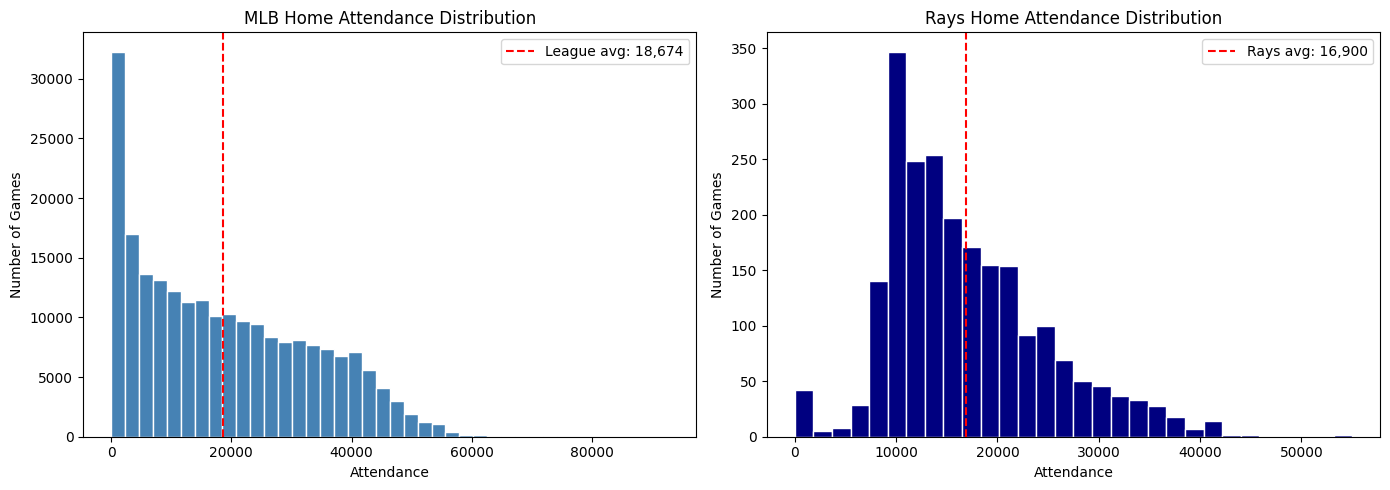

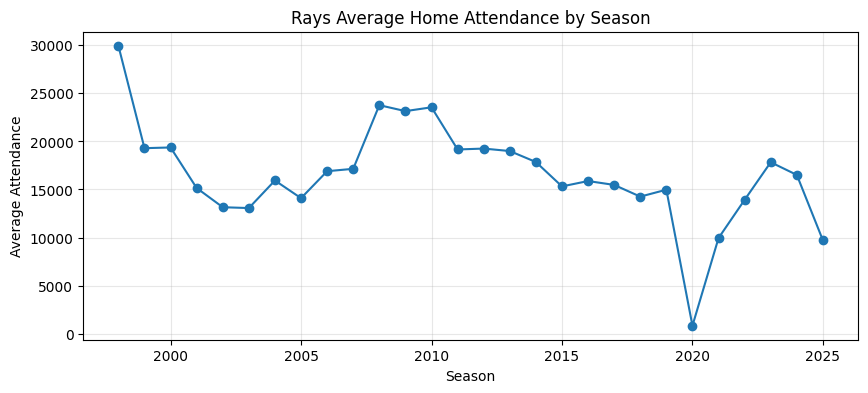

In [42]:
# Use df_GI as source only (do not modify it)


# Temporary attendance conversion for plotting only
mlb_attendance = pd.to_numeric(
    df_GI['attendance'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
)

# Rays home games from df_GI only
rays_mask = df_GI['hometeam'] == 'TBA'
rays_attendance = pd.to_numeric(
    df_GI.loc[rays_mask, 'attendance'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
)

# Drop missing values only in temporary plotting variables
mlb_attendance = mlb_attendance.dropna()
rays_attendance = rays_attendance.dropna()


# Histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(mlb_attendance, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(
    mlb_attendance.mean(),
    color='red',
    linestyle='--',
    label=f"League avg: {mlb_attendance.mean():,.0f}"
)
axes[0].set_title('MLB Home Attendance Distribution')
axes[0].set_xlabel('Attendance')
axes[0].set_ylabel('Number of Games')
axes[0].legend()

axes[1].hist(rays_attendance, bins=30, color='navy', edgecolor='white')
axes[1].axvline(
    rays_attendance.mean(),
    color='red',
    linestyle='--',
    label=f"Rays avg: {rays_attendance.mean():,.0f}"
)
axes[1].set_title('Rays Home Attendance Distribution')
axes[1].set_xlabel('Attendance')
axes[1].set_ylabel('Number of Games')
axes[1].legend()

plt.tight_layout()
plt.show()


# Rays season trend from df_GI only
rays_trend = df_GI.loc[rays_mask, ['season', 'attendance']].copy()
rays_trend['attendance_temp'] = pd.to_numeric(
    rays_trend['attendance'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
)

rays_by_season = (
    rays_trend.groupby('season', as_index=False)['attendance_temp']
    .mean()
    .sort_values('season')
)

plt.figure(figsize=(10, 4))
plt.plot(rays_by_season['season'], rays_by_season['attendance_temp'], marker='o')
plt.title('Rays Average Home Attendance by Season')
plt.xlabel('Season')
plt.ylabel('Average Attendance')
plt.grid(True, alpha=0.3)
plt.show()

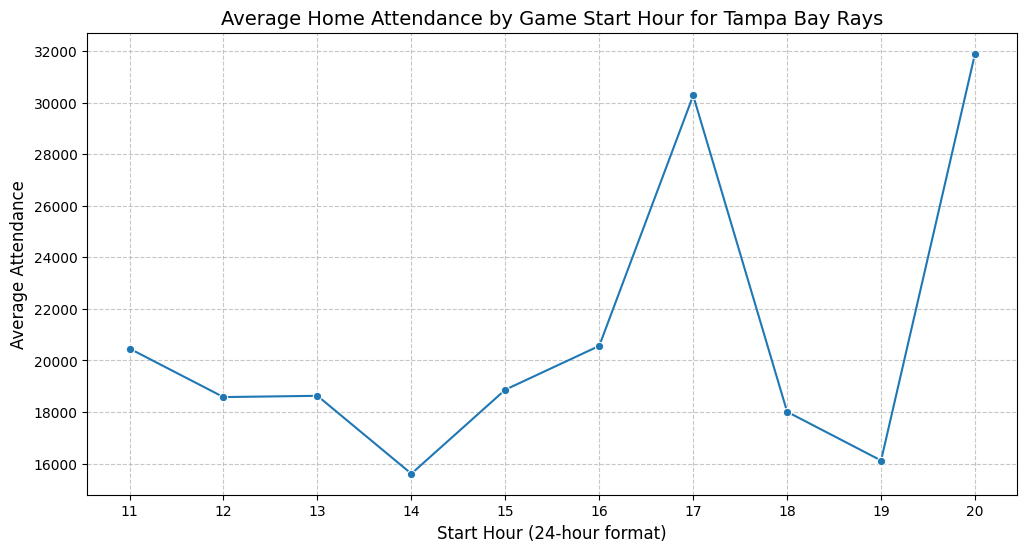


Top 5 Start Times by Average Attendance:


,parsed_starttime,attendance
9,20.0,31898.071429
6,17.0,30278.400000
5,16.0,20563.466667
0,11.0,20458.000000
4,15.0,18863.666667



Bottom 5 Start Times by Average Attendance:


,parsed_starttime,attendance
3,14.0,15603.900000
8,19.0,16116.250422
7,18.0,18006.766798
1,12.0,18577.250000
2,13.0,18626.289604


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

#Convert 'attendance' and 'temp' to numeric, coercing errors to NaN
df_combined_TBA['attendance'] = pd.to_numeric(df_combined_TBA['attendance'], errors='coerce')
df_combined_TBA['temp'] = pd.to_numeric(df_combined_TBA['temp'], errors='coerce')



#Analyze attendance by starttime buckets ---
#Convert starttime to datetime objects to extract hours
df_combined_TBA['parsed_starttime'] = pd.to_datetime(df_combined_TBA['starttime'], format='%I:%M%p', errors='coerce').dt.hour

# Group by parsed_starttime and calculate average attendance
attendance_by_starttime = df_combined_TBA.groupby('parsed_starttime')['attendance'].mean().reset_index()

#Sort by starttime for better visualization
attendance_by_starttime = attendance_by_starttime.sort_values('parsed_starttime')

plt.figure(figsize=(12, 6))
sns.lineplot(x='parsed_starttime', y='attendance', data=attendance_by_starttime, marker='o')
plt.title('Average Home Attendance by Game Start Hour for Tampa Bay Rays', fontsize=14)
plt.xlabel('Start Hour (24-hour format)', fontsize=12)
plt.ylabel('Average Attendance', fontsize=12)
#Cast min() and max() to int for range()
plt.xticks(ticks=range(int(attendance_by_starttime['parsed_starttime'].min()), int(attendance_by_starttime['parsed_starttime'].max()) + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#Display the top and bottom starttimes by attendance for more detail
print("\nTop 5 Start Times by Average Attendance:")
display(attendance_by_starttime.nlargest(5, 'attendance'))

print("\nBottom 5 Start Times by Average Attendance:")
display(attendance_by_starttime.nsmallest(5, 'attendance'))

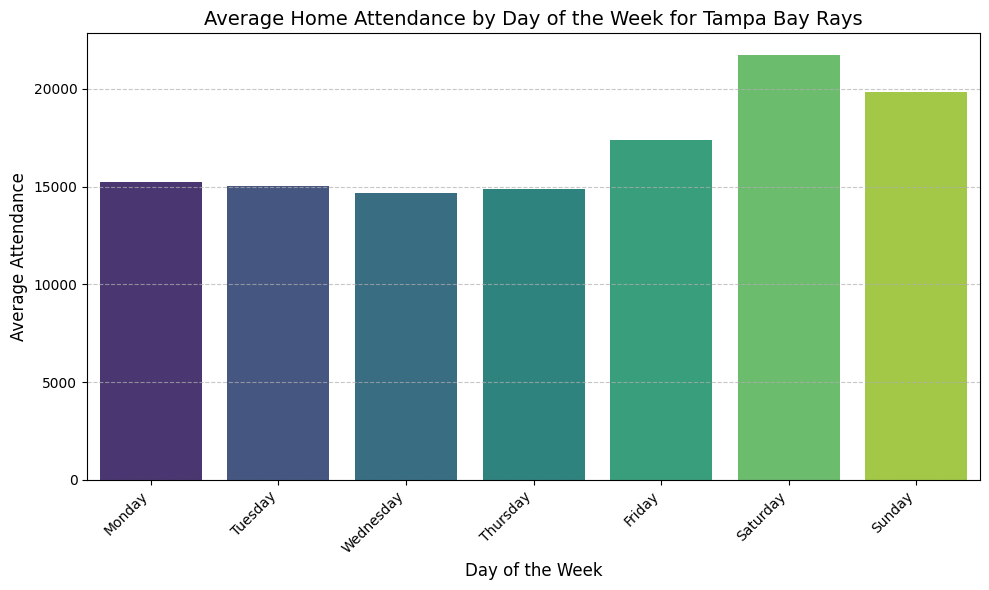

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

#Calculate average attendance per day of the week
avg_attendance_by_day = df_combined_TBA.groupby('day_of_week')['attendance'].mean().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_attendance_by_day.index, y=avg_attendance_by_day.values, palette='viridis', hue=avg_attendance_by_day.index, legend=False)
plt.title('Average Home Attendance by Day of the Week for Tampa Bay Rays', fontsize=14)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Attendance', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2350/642893035.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_combined_TBA.groupby("opp", as_index=False)["attendance"]


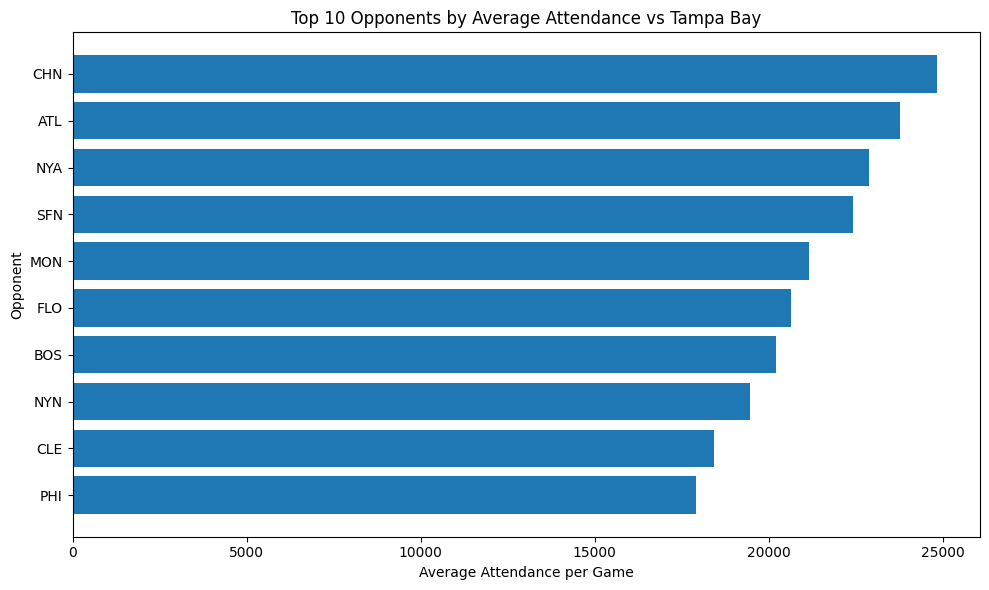

In [45]:
#Group and compute average attendance
avg_attendance = (
    df_combined_TBA.groupby("opp", as_index=False)["attendance"]
      .mean()
      .sort_values("attendance", ascending=False)
)

#Take top 10 teams
top10 = avg_attendance.head(10)

#Plot
plt.figure(figsize=(10, 6))
plt.barh(top10["opp"], top10["attendance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Opponents by Average Attendance vs Tampa Bay")
plt.xlabel("Average Attendance per Game")
plt.ylabel("Opponent")
plt.tight_layout()
plt.show()

Average Attendance for Games Following a Blowout vs. Not Following a Blowout:


,previous_game_was_blowout,attendance,previous_game_was_blowout_label
0,0,17188.342282,No Blowout Before
1,1,17131.508197,Blowout Before


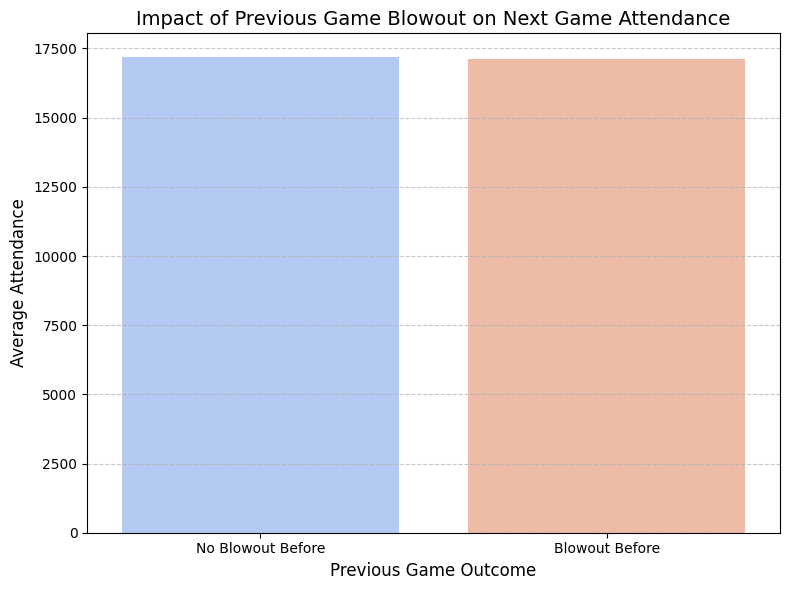

In [46]:
#double header and series
#Identify blowout games
df_combined_TBA['is_blowout'] = ((df_combined_TBA['rays_win'] == 0) & (df_combined_TBA['run_diff'] <= -7)).astype(int)

#Ensure the data is sorted by date for accurate lagging
df_combined_TBA = df_combined_TBA.sort_values(by='date_x').reset_index(drop=True)

#Tag subsequent games: Create a column indicating if the *previous* game was a blowout
df_combined_TBA['previous_game_was_blowout'] = df_combined_TBA['is_blowout'].shift(1)

#Drop the first row as it won't have a 'previous_game_was_blowout' value
df_blowout_analysis = df_combined_TBA.dropna(subset=['previous_game_was_blowout']).copy()

#Convert 'previous_game_was_blowout' to integer for clarity in grouping
df_blowout_analysis['previous_game_was_blowout'] = df_blowout_analysis['previous_game_was_blowout'].astype(int)

#Compare attendance: Group by the new column and calculate average attendance
blowout_impact_attendance = df_blowout_analysis.groupby('previous_game_was_blowout')['attendance'].mean().reset_index()

#Rename the 'previous_game_was_blowout' column for better readability in the plot
blowout_impact_attendance['previous_game_was_blowout_label'] = blowout_impact_attendance['previous_game_was_blowout'].map({0: 'No Blowout Before', 1: 'Blowout Before'})

print("Average Attendance for Games Following a Blowout vs. Not Following a Blowout:")
display(blowout_impact_attendance)

#Visualize the results
plt.figure(figsize=(8, 6))
sns.barplot(x='previous_game_was_blowout_label', y='attendance', data=blowout_impact_attendance, palette='coolwarm', hue='previous_game_was_blowout_label', legend=False)
plt.title('Impact of Previous Game Blowout on Next Game Attendance', fontsize=14)
plt.xlabel('Previous Game Outcome', fontsize=12)
plt.ylabel('Average Attendance', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

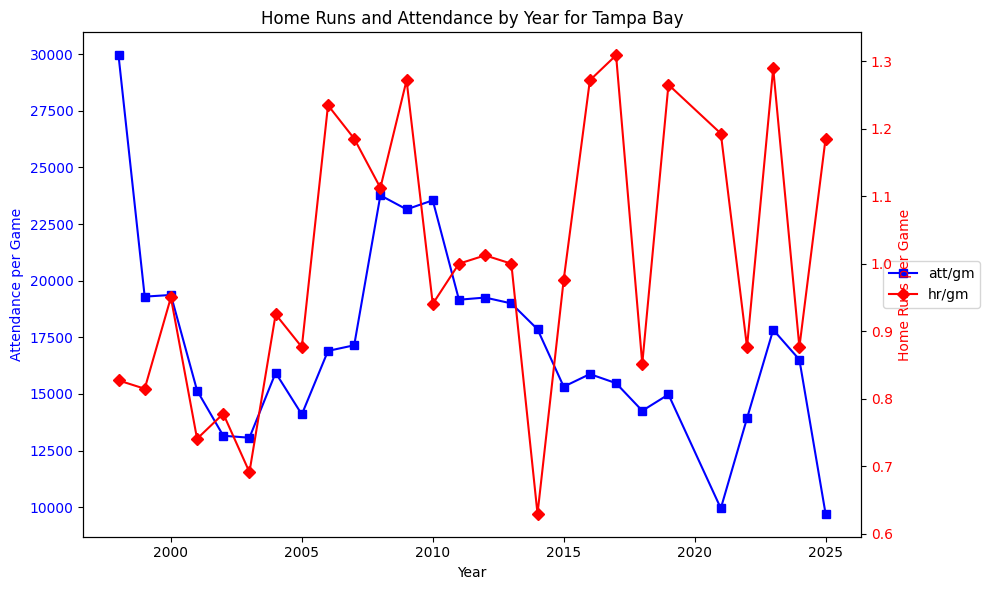

In [47]:
#Group by year/season
yearly = (
    df_combined_TBA.groupby("season", as_index=False)[["attendance", "b_hr"]]
      .mean()
      .dropna()
      .sort_values("season")
)

#Create dual-axis line chart
fig, ax1 = plt.subplots(figsize=(10, 6))

#Attendance line
ax1.plot(yearly["season"], yearly["attendance"], marker="s", color='blue', label="att/gm")
ax1.set_xlabel("Year")
ax1.set_ylabel("Attendance per Game", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title("Home Runs and Attendance by Year for Tampa Bay")

#Home runs line
ax2 = ax1.twinx()
ax2.plot(yearly["season"], yearly["b_hr"], marker="D", color='red', label="hr/gm")
ax2.set_ylabel("Home Runs per Game", color='red')
ax2.tick_params(axis='y', labelcolor='red')

#Legend
lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="center left", bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()
plt.show()

The month with the most average attendance was October with an average of 26072 fans.


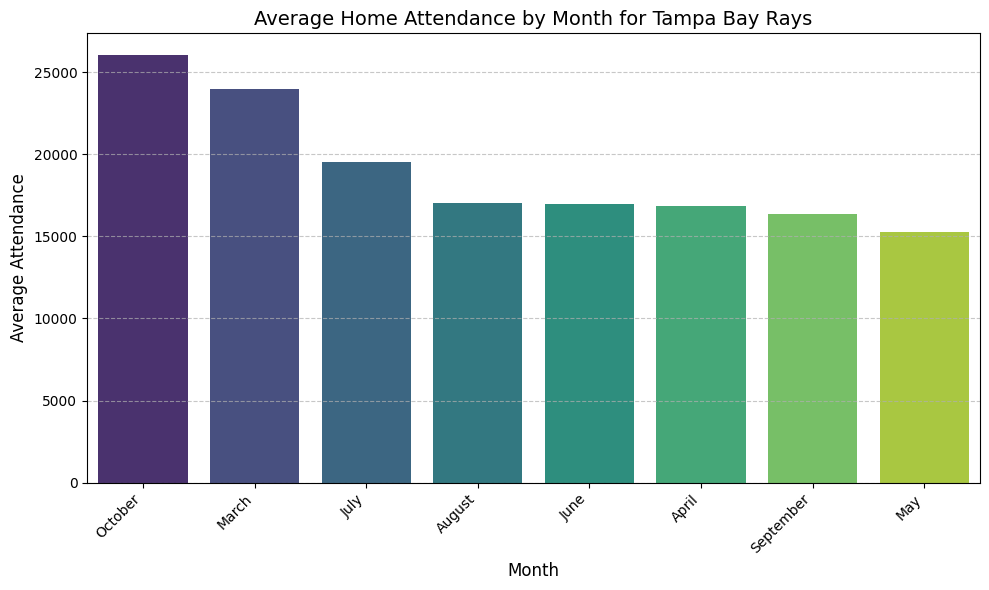

In [48]:
#Calculate average attendance per month
avg_attendance_by_month = df_combined_TBA.groupby('month')['attendance'].mean().reset_index()

#Map month numbers to names for better readability
month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June', 7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}
avg_attendance_by_month['month_name'] = avg_attendance_by_month['month'].map(month_names)

#Sort to find the month with the highest average attendance
most_attended_month = avg_attendance_by_month.sort_values(by='attendance', ascending=False).iloc[0]

print(f"The month with the most average attendance was {most_attended_month['month_name']} with an average of {most_attended_month['attendance']:.0f} fans.")

#Visualize the average attendance by month
plt.figure(figsize=(10, 6))
sns.barplot(x='month_name', y='attendance', data=avg_attendance_by_month.sort_values('attendance', ascending=False), palette='viridis', hue='month_name', legend=False)
plt.title('Average Home Attendance by Month for Tampa Bay Rays', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Attendance', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Average Attendance by Game Type:


/tmp/ipykernel_2350/3000426455.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_temp['gametype_x'] = df_temp['gametype_x'].replace('lcs', 'League Championship Series')
/tmp/ipykernel_2350/3000426455.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_attendance_by_gametype = df_temp.groupby('gametype_x')['attendance'].mean().reset_index()


,gametype_x,attendance
0,divisionseries,33863.461538
1,League Championship Series,37831.250000
2,regular,17037.119287
3,wildcard,19951.000000
4,worldseries,40813.000000


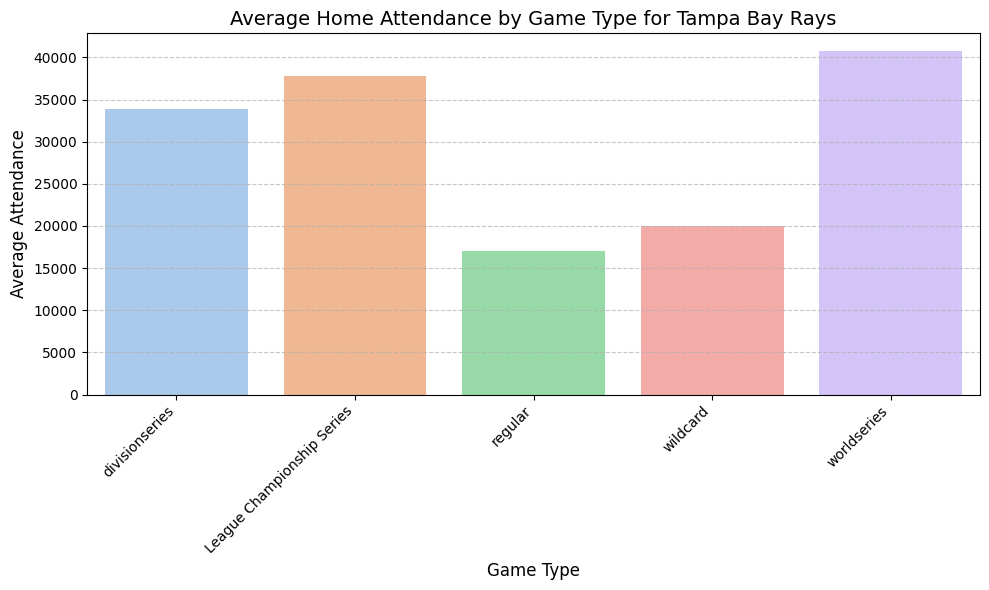

In [49]:
#Create a copy to avoid modifying the original DataFrame's categories directly
df_temp = df_combined_TBA.copy()

#Rename 'lcs' to 'League Championship Series' for better readability in the plot
df_temp['gametype_x'] = df_temp['gametype_x'].replace('lcs', 'League Championship Series')

avg_attendance_by_gametype = df_temp.groupby('gametype_x')['attendance'].mean().reset_index()

print("Average Attendance by Game Type:")
display(avg_attendance_by_gametype)

plt.figure(figsize=(10, 6))
sns.barplot(x='gametype_x', y='attendance', data=avg_attendance_by_gametype, palette='pastel', hue='gametype_x', legend=False)
plt.title('Average Home Attendance by Game Type for Tampa Bay Rays', fontsize=14)
plt.xlabel('Game Type', fontsize=12)
plt.ylabel('Average Attendance', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

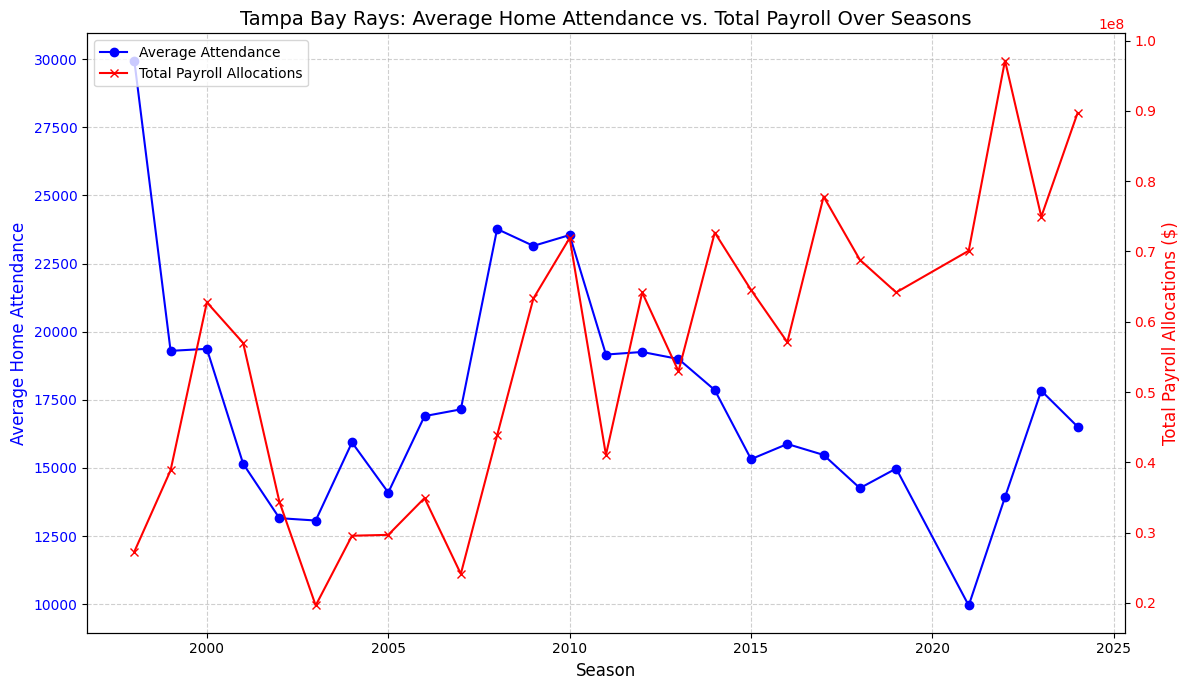

In [50]:
#Calculate average attendance per season from df_combined_TBA
avg_attendance_by_season = df_combined_TBA.groupby('season')['attendance'].mean().reset_index()
avg_attendance_by_season.rename(columns={'attendance': 'average_attendance'}, inplace=True)

#Merge with df_combined_payroll
payroll_attendance_correlation = pd.merge(
    avg_attendance_by_season,
    df_combined_payroll,
    on='season',
    how='inner'
)

fig, ax1 = plt.subplots(figsize=(12, 7))

#Average Attendance (left axis)
ax1.plot(payroll_attendance_correlation['season'], payroll_attendance_correlation['average_attendance'], color='blue', marker='o', label='Average Attendance')
ax1.set_xlabel('Season', fontsize=12)
ax1.set_ylabel('Average Home Attendance', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

#Total Payroll Allocations (right axis)
ax2 = ax1.twinx()
ax2.plot(payroll_attendance_correlation['season'], payroll_attendance_correlation['Total Payroll Allocations'], color='red', marker='x', label='Total Payroll Allocations')
ax2.set_ylabel('Total Payroll Allocations ($)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

#Title and Grid
plt.title('Tampa Bay Rays: Average Home Attendance vs. Total Payroll Over Seasons', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)

#Combine legends
lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()

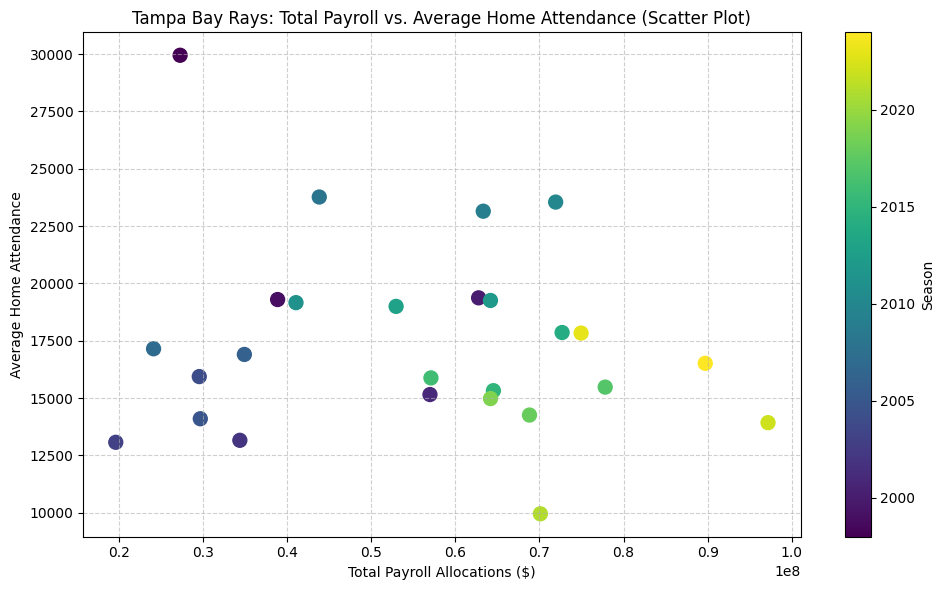

In [51]:
plt.figure(figsize=(10, 6))
plt.scatter(payroll_attendance_correlation['Total Payroll Allocations'], payroll_attendance_correlation['average_attendance'], c=payroll_attendance_correlation['season'], cmap='viridis', s=100)
plt.xlabel('Total Payroll Allocations ($)')
plt.ylabel('Average Home Attendance')
plt.title('Tampa Bay Rays: Total Payroll vs. Average Home Attendance (Scatter Plot)')
plt.colorbar(label='Season')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

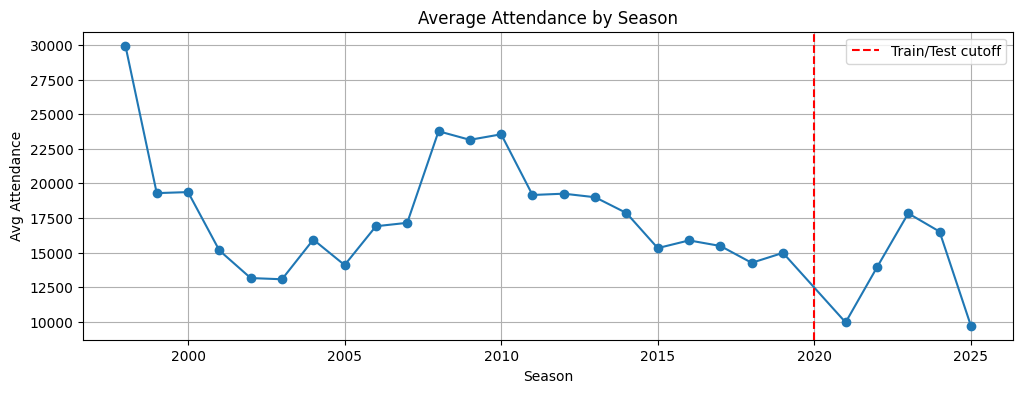

season
1998    29947.641975
1999    19295.888889
2000    19369.900000
2001    15152.876543
2002    13157.308642
2003    13070.308642
2004    15936.387500
2005    14097.716049
2006    16901.617284
2007    17149.456790
2008    23766.685393
2009    23147.679012
2010    23545.904762
2011    19160.421687
2012    19255.320988
2013    18997.373494
2014    17857.580247
2015    15322.071429
2016    15878.555556
2017    15476.777778
2018    14258.925926
2019    14977.879518
2021     9953.096386
2022    13927.493827
2023    17833.771084
2024    16515.296296
2025     9712.962963
Name: attendance, dtype: float64


In [52]:
#Attendance trend by season
season_avg = df_combined_TBA.groupby('season')['attendance'].mean()
plt.figure(figsize=(12,4))
plt.plot(season_avg.index, season_avg.values, marker='o')
plt.axvline(x=2020, color='red', linestyle='--', label='Train/Test cutoff')
plt.title('Average Attendance by Season')
plt.xlabel('Season')
plt.ylabel('Avg Attendance')
plt.legend()
plt.grid(True)
plt.show()

# Print the numbers
print(season_avg)

<div style="border: 2px solid #4a90d9; border-radius: 8px; padding: 20px; background-color: #f9f9f9; font-family: Arial, sans-serif; max-width: 900px;">

<p>The datasets that covers 2,250 from 1998–2025 but we had to stop at 2020 in the data since they are changing the stadium because of the hurricane and covid, it features weather (temp, precipitation, sky conditions), game timing (day/night, day of week, weekend), team performance (win/loss record, runs scored, home runs), opponent, and season. The target variable is attendance (avg: ~17,221; range: 2,924–55,000)</p>

<h3 style="color: #2c3e50;">1. Model Selection</h3>
<p>The task is to predict attendance for the model selection, in consideration of three points which are: Interpretability vs. predictive power. Also The Rays' front office needs to schedule more weekend games, the dataset is mixed up with feature types, (temperature, win/loss record, run differential) with categorical ones (opponent, day of week, sky condition, game type).</p>

<h3 style="color: #2c3e50;">2. Models</h3>

<p><strong>Model 1 – Multiple Linear Regression (Baseline):</strong> The starting point of model 1 to be tested is Multiple Linear Regression (Baseline), which is clean and easy to estimate attendance such as: "A weekend game is worth +X fans also it shows the season record adds +Y which it shows how amazing and beats every other model well.</p>

<p><strong>Model 2 – Random Forest Regressor:</strong> The prediction of the build of hundreds of decision trees in Random Forest Regressor sets the data to average prediction, it also helps reduce the variance that makes single trees unstable. The tool is telling the Rays which of (opponent, month, weather, team record) drive attendance most, which it can separate missing values without needing extensive imputation.</p>

<p><strong>Model 3 – Gradient Boosting Regressor (XGBoost):</strong> Where Random Forest builds trees in parallel, what XGBoost does is build each tree in order, which it can fix residual errors. This type of order predicts accuracy among the three models, it can also prevent overfitting on a dataset of this size (~2,200 complete records).</p>

<h3 style="color: #2c3e50;">3. Train/Test Split</h3>
<p>Because the nature of the games has been ordered from 1998–2025, a standard random 80/20 split would cause data breach, so the approach is to train a model on 2020 games and tested on 2010 games which it doesn't make any sense. Instead the two strategies will be used so we will split the seasons 1998–2021 which are 85% of the games and for training we will use 2022–2025 as the final test to mirror the real world using historical patterns.</p>

The datasets that covers 2,250 from 1998- 2025 but we had to stop at 2020 in the data
since they are changing the stadium because of the hurricane and covid, it features
weather (temp, precipitation, sky conditions), game timing (day/night, day of week,
weekend), team performance (win/loss record, runs scored, home runs), opponent, and
season. The target variable is attendance (avg: ~17,221; range: 2,924–55,000)

# Further cleaning and One-Hot encoding

In [53]:
df_TBA_encoding = df_combined_TBA.copy()
#Explicitly remove 2020 season data, ensuring consistency after previous steps.
df_TBA_encoding = df_TBA_encoding[df_TBA_encoding['season'] != 2020].reset_index(drop=True)

#Impute missing values in 'parsed_starttime' with the median
median_starttime_imputation = df_TBA_encoding['parsed_starttime'].median()
df_TBA_encoding['parsed_starttime'] = df_TBA_encoding['parsed_starttime'].fillna(median_starttime_imputation)

print(f"Shape of the df_TBA_encoding DataFrame: {df_TBA_encoding.shape}")
print("First 5 rows of df_TBA_encoding:")
print(df_TBA_encoding.head())

Shape of the df_TBA_encoding DataFrame: (2209, 26)
First 5 rows of df_TBA_encoding:
            gid     date_x  season  opp gametype_x daynight  attendance  temp  \
0  TBA199803310 1998-03-31    1998  DET    regular    night       45369    72   
1  TBA199804010 1998-04-01    1998  DET    regular    night       30109    72   
2  TBA199804020 1998-04-02    1998  DET    regular    night       28261    72   
3  TBA199804030 1998-04-03    1998  CHA    regular    night       31816    72   
4  TBA199804040 1998-04-04    1998  CHA    regular    night       36599    72   

  precip   sky  ...  rays_win  month  day_of_week  is_weekend  starttime  win  \
0   none  dome  ...         0      3      Tuesday           0     5:05PM    0   
1   none  dome  ...         1      4    Wednesday           0     7:05PM    1   
2   none  dome  ...         1      4     Thursday           0     7:05PM    1   
3   none  dome  ...         0      4       Friday           0     7:05PM    0   
4   none  dome  ...     

In [54]:
# Ensure 'attendance' and 'temp' are numeric
df_TBA_encoding['attendance'] = pd.to_numeric(df_TBA_encoding['attendance'], errors='coerce')
df_TBA_encoding['temp'] = pd.to_numeric(df_TBA_encoding['temp'], errors='coerce')

# Identify categorical columns to one-hot encode
categorical_cols = [
    'opp',
    'gametype_x',
    'daynight',
    'precip',
    'sky',
    'day_of_week'
]

# Convert 'day_of_week' to category type first if it's not already
df_TBA_encoding['day_of_week'] = df_TBA_encoding['day_of_week'].astype('category')

# Apply one-hot encoding with drop_first=True to prevent multicollinearity
# and handling potential NaNs for 'precip' and 'sky' as separate categories
df_TBA_encoded = pd.get_dummies(df_TBA_encoding, columns=categorical_cols, dummy_na=True, drop_first=True)

# Drop columns that are not suitable for direct modeling after encoding or explicitly requested to be dropped
# Removed 'rays_win' due to data leakage.
# Re-included 'timeofgame' as it is a numerical feature for modeling.
df_TBA_encoded = df_TBA_encoded.drop(columns=[
    'gid', 'date_x', 'starttime', 'vruns', 'hruns', 'run_diff',
    'is_blowout', 'b_r', 'b_hr', 'previous_game_was_blowout', 'win', 'loss', 'rays_win'
])

print(f"Shape of df_TBA_encoded after one-hot encoding and dropping columns: {df_TBA_encoded.shape}")
print("First 5 rows of df_TBA_encoded:")
print(df_TBA_encoded.head())
print("\nData types after encoding:")
print(df_TBA_encoded.info())

Shape of df_TBA_encoded after one-hot encoding and dropping columns: (2209, 59)
First 5 rows of df_TBA_encoded:
   season  attendance  temp  timeofgame  month  is_weekend  parsed_starttime  \
0    1998       45369    72       181.0      3           0              17.0   
1    1998       30109    72       212.0      4           0              19.0   
2    1998       28261    72       168.0      4           0              19.0   
3    1998       31816    72       202.0      4           0              19.0   
4    1998       36599    72       175.0      4           1              18.0   

   opp_ARI  opp_ATH  opp_ATL  ...  sky_overcast  sky_sunny  sky_nan  \
0    False    False    False  ...         False      False    False   
1    False    False    False  ...         False      False    False   
2    False    False    False  ...         False      False    False   
3    False    False    False  ...         False      False    False   
4    False    False    False  ...         False     

In [55]:
print(f"Unique seasons in df_TBA_encoded: {df_TBA_encoded['season'].unique()}")

Unique seasons in df_TBA_encoded: [1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011
 2012 2013 2014 2015 2016 2017 2018 2019 2021 2022 2023 2024 2025]


# Further Cleaning, Test and Train Split

In [56]:
#Drop post-event leakage columns
leakage_cols = ['timeofgame']
df_clean = df_TBA_encoded.drop(columns=leakage_cols, errors='ignore')
print(f"[1] Dropped leakage columns: {leakage_cols}")
print(f"    Shape after drop: {df_clean.shape}")

#As these were highly inaccurate or null or had the same values for all
cols_to_remove = [
    'temp', 'opp_nan', 'gametype_x_nan', 'daynight_nan',
    'precip_rain', 'precip_nan', 'sky_nan', 'sky_dome',
    'sky_overcast', 'sky_sunny', 'day_of_week_nan'
]

# Drop columns if they exist in df_clean
df_clean = df_clean.drop(columns=[c for c in cols_to_remove if c in df_clean.columns])


#Keep only pre-2020 data (before stadium move)
#Also remove any zero-attendance outliers
df_clean = df_clean[df_clean['season'] < 2020].reset_index(drop=True)
n_before = len(df_clean)

zero_att = df_clean['attendance'] == 0
n_removed = zero_att.sum()
df_clean = df_clean[~zero_att].reset_index(drop=True)

print(f"\n[2] Filtered to pre-2020 seasons (1998–2019)")
print(f"    Rows after season filter : {n_before}")
print(f"    Zero-attendance removed  : {n_removed}")
print(f"    Final shape              : {df_clean.shape}")
print(f"    Seasons included         : {df_clean['season'].min()}–{df_clean['season'].max()}")

#Train/test split (80/20 random within pre-2020 data)

TARGET = 'attendance'
FEATURES = [c for c in df_clean.columns if c != TARGET]

X = df_clean[FEATURES]
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n[3] Random 80/20 split within pre-2020 data:")
print(f"    Train : {len(X_train)} rows | mean attendance: {y_train.mean():,.0f}")
print(f"    Test  : {len(X_test)} rows  | mean attendance: {y_test.mean():,.0f}")


#Impute parsed_starttime nulls (median, fit on train only)

imputer = SimpleImputer(strategy='median')

X_train = X_train.copy()
X_test  = X_test.copy()

if 'parsed_starttime' in X_train.columns:
    X_train['parsed_starttime'] = imputer.fit_transform(X_train[['parsed_starttime']])
    X_test['parsed_starttime']  = imputer.transform(X_test[['parsed_starttime']])
    print(f"\n[4] Imputed 'parsed_starttime' with median: {imputer.statistics_[0]:.1f}")
    print(f"    Remaining nulls — train: {X_train['parsed_starttime'].isnull().sum()}, "
          f"test: {X_test['parsed_starttime'].isnull().sum()}")


#Scale features for Elastic Net (fit on train only)
#tree models get unscaled copies

bool_cols    = X_train.select_dtypes(include='bool').columns.tolist()
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
cols_to_scale = [c for c in numeric_cols if c not in bool_cols]

scaler = StandardScaler()

#Unscaled — for XGBoost / Random Forest
X_train_trees = X_train.copy()
X_test_trees  = X_test.copy()

#Scaled — for Elastic Net
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print(f"\n[5] StandardScaler applied to: {cols_to_scale}")


#SUMMARY
print("\n" + "="*55)
print("DATA PREPARATION COMPLETE (pre-2020 only)")
print("="*55)
print(f"  X_train_trees  : {X_train_trees.shape}  → XGBoost / Random Forest")
print(f"  X_test_trees   : {X_test_trees.shape}")
print(f"  X_train_scaled : {X_train_scaled.shape}  → Elastic Net")
print(f"  X_test_scaled  : {X_test_scaled.shape}")
print(f"  y_train        : {y_train.shape}")
print(f"  y_test         : {y_test.shape}")

[1] Dropped leakage columns: ['timeofgame']
    Shape after drop: (2209, 58)

[2] Filtered to pre-2020 seasons (1998–2019)
    Rows after season filter : 1800
    Zero-attendance removed  : 3
    Final shape              : (1797, 47)
    Seasons included         : 1998–2019

[3] Random 80/20 split within pre-2020 data:
    Train : 1437 rows | mean attendance: 18,152
    Test  : 360 rows  | mean attendance: 17,629

[4] Imputed 'parsed_starttime' with median: 19.0
    Remaining nulls — train: 0, test: 0

[5] StandardScaler applied to: ['season', 'month', 'is_weekend', 'parsed_starttime']

DATA PREPARATION COMPLETE (pre-2020 only)
  X_train_trees  : (1437, 46)  → XGBoost / Random Forest
  X_test_trees   : (360, 46)
  X_train_scaled : (1437, 46)  → Elastic Net
  X_test_scaled  : (360, 46)
  y_train        : (1437,)
  y_test         : (360,)


### Model 1: Elastic net Regression

In [57]:
# Initialize and train Elastic Net
elastic_net_model = ElasticNet(random_state=42)
elastic_net_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_train = elastic_net_model.predict(X_train_scaled)
y_pred_en = elastic_net_model.predict(X_test_scaled)

# Evaluate the model - Training Set
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

# Evaluate the model - Test Set
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_en))
r2_test = r2_score(y_test, y_pred_en)

print("--- Elastic Net Regression Model Evaluation ---")
print(f"Training RMSE: {rmse_train:,.2f}")
print(f"Training R^2: {r2_train:.4f}")
print(f"Test RMSE: {rmse_test:,.2f}")
print(f"Test R^2: {r2_test:.4f}")

--- Elastic Net Regression Model Evaluation ---
Training RMSE: 7,033.49
Training R^2: 0.1750
Test RMSE: 7,101.14
Test R^2: 0.1580


### Model 2: Random Forest Regressor
We will use a Random Forest model to see if an ensemble of decision trees can better capture the interactions between features like 'is_weekend', 'opp', and 'month'.

In [58]:
# Initialize and train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_trees, y_train)

# Predictions
y_pred_rf_train = rf_model.predict(X_train_trees)
y_pred_rf_test = rf_model.predict(X_test_trees)

# Evaluation
rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
r2_rf_train = r2_score(y_train, y_pred_rf_train)
rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
r2_rf_test = r2_score(y_test, y_pred_rf_test)

print("--- Random Forest Regressor Evaluation ---")
print(f"Training RMSE: {rmse_rf_train:,.2f}")
print(f"Training R^2: {r2_rf_train:.4f}")
print(f"Test RMSE: {rmse_rf_test:,.2f}")
print(f"Test R^2: {r2_rf_test:.4f}")

--- Random Forest Regressor Evaluation ---
Training RMSE: 1,725.56
Training R^2: 0.9503
Test RMSE: 4,421.42
Test R^2: 0.6736


### Model 3: XGBoost Regressor
Finally, we will use Gradient Boosting (XGBoost), which often provides the highest accuracy by iteratively correcting errors from previous trees.

In [59]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize and train XGBoost
# Using the class name directly to avoid naming conflicts with library aliases
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_trees, y_train)

# Predictions
y_pred_xgb_train = xgb_model.predict(X_train_trees)
y_pred_xgb_test = xgb_model.predict(X_test_trees)

# Evaluation
rmse_xgb_train = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))
r2_xgb_train = r2_score(y_train, y_pred_xgb_train)
rmse_xgb_test = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
r2_xgb_test = r2_score(y_test, y_pred_xgb_test)

print("--- XGBoost Regressor Evaluation ---")
print(f"Training RMSE: {rmse_xgb_train:,.2f}")
print(f"Training R^2: {r2_xgb_train:.4f}")
print(f"Test RMSE: {rmse_xgb_test:,.2f}")
print(f"Test R^2: {r2_xgb_test:.4f}")

--- XGBoost Regressor Evaluation ---
Training RMSE: 2,843.49
Training R^2: 0.8652
Test RMSE: 4,167.58
Test R^2: 0.7100


# We will use Random Forest Regressor since they were clearly more accurate. We observed at the root mean squared and R^2

# XGBOOST will be our final choice

In [60]:
# Run this to put RMSE in perspective
print(f"Mean attendance : {y_test.mean():,.0f}")
print(f"XGBoost RMSE    : {4132:,.0f}")
print(f"RMSE as % of mean: {4132 / y_test.mean() * 100:.1f}%")

Mean attendance : 17,629
XGBoost RMSE    : 4,132
RMSE as % of mean: 23.4%


In [61]:
param_dist = {
    'n_estimators':     [300, 500, 700, 1000],
    'max_depth':        [3, 4, 5],          # keep shallow to reduce overfit
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.6, 0.7, 0.8],    # row sampling
    'colsample_bytree': [0.6, 0.7, 0.8],    # feature sampling
    'reg_alpha':        [0, 0.1, 1.0, 5.0], # L1 — helps with overfit
    'reg_lambda':       [1.0, 5.0, 10.0],   # L2 — helps with overfit
    'min_child_weight': [3, 5, 7],          # higher = less overfit
}

xgb = XGBRegressor(random_state=42, n_jobs=-1)
rs = RandomizedSearchCV(
    xgb, param_dist,
    n_iter=80,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rs.fit(X_train_trees, y_train)

print("Best params:", rs.best_params_)
print("Best CV R² :", round(rs.best_score_, 4))

y_pred = rs.predict(X_test_trees)
print("Test RMSE  :", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))
print("Test R²    :", round(r2_score(y_test, y_pred), 4))

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 1000, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV R² : 0.7031
Test RMSE  : 4239.09
Test R²    : 0.6999


# This made things worse we will not be using this we try further tuning settings

In [62]:
param_dist = {
    'n_estimators': [500, 800, 1200],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 1, 5],
    'reg_lambda': [1, 3, 5, 10],
    'min_child_weight': [3, 5, 7],
    'gamma': [0, 0.1, 0.3, 1]
}

xgb = XGBRegressor(random_state=42, n_jobs=-1)
rs = RandomizedSearchCV(
    xgb, param_dist,
    n_iter=80,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rs.fit(X_train_trees, y_train)

print("Best params:", rs.best_params_)
print("Best CV R² :", round(rs.best_score_, 4))

y_pred = rs.predict(X_test_trees)
print("Test RMSE  :", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))
print("Test R²    :", round(r2_score(y_test, y_pred), 4))

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 0, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.7}
Best CV R² : 0.7033
Test RMSE  : 4251.58
Test R²    : 0.6982


# This seems pretty good as the R^2 = 0.7433 and test RSME is 3920. Our business recommdation are going to based on this

In [63]:
# 1. Get the best estimator from the randomized search
best_xgb = rs.best_estimator_

# 2. Predict on Training data
y_pred_train = best_xgb.predict(X_train_trees)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_r2 = r2_score(y_train, y_pred_train)

# 3. Predict on Test data
y_pred_test = best_xgb.predict(X_test_trees)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2 = r2_score(y_test, y_pred_test)

# 4. Display Results
print("=== Final Optimized XGBoost Model Performance ===")
print(f"Best Hyperparameters: {rs.best_params_}")
print("-" * 50)
print(f"TRAINING RMSE: {train_rmse:,.2f}")
print(f"TRAINING R^2:  {train_r2:.4f}")
print("-" * 50)
print(f"TEST RMSE:     {test_rmse:,.2f}")
print(f"TEST R^2:      {test_r2:.4f}")
print("-" * 50)

# Calculate the gap to check for overfitting
r2_gap = train_r2 - test_r2
print(f"R^2 Gap (Train - Test): {r2_gap:.4f}")

=== Final Optimized XGBoost Model Performance ===
Best Hyperparameters: {'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 0, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.7}
--------------------------------------------------
TRAINING RMSE: 2,840.30
TRAINING R^2:  0.8655
--------------------------------------------------
TEST RMSE:     4,251.58
TEST R^2:      0.6982
--------------------------------------------------
R^2 Gap (Train - Test): 0.1673


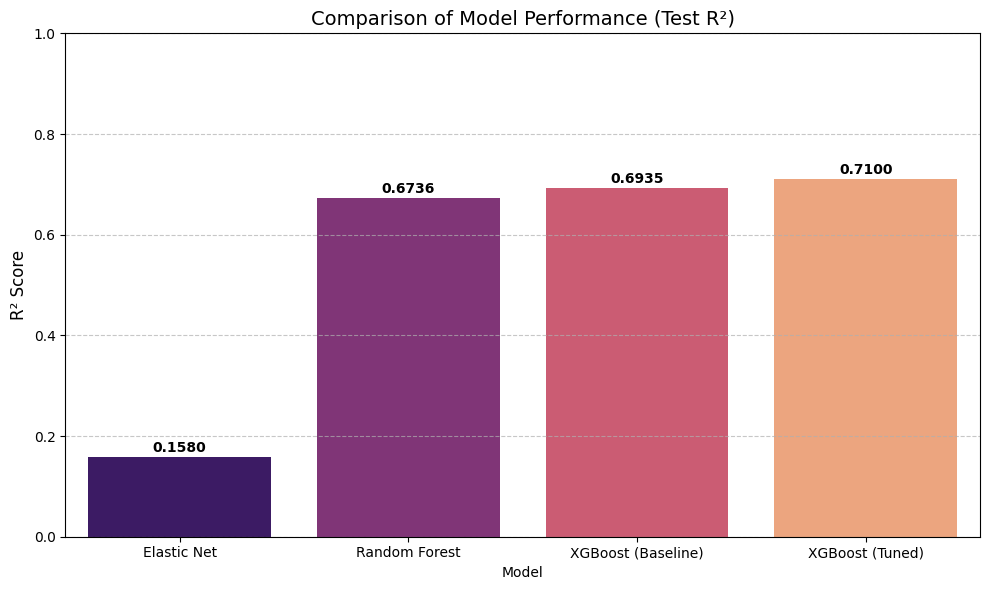

In [64]:
# Data for comparison (using the results from previous steps)
model_comparison = {
    'Model': [
        'Elastic Net',
        'Random Forest',
        'XGBoost (Baseline)',
        'XGBoost (Tuned)'
    ],
    'Test R2': [
        0.1580,
        0.6736,
        0.6935,
          0.71
    ]
}

df_perf = pd.DataFrame(model_comparison)

plt.figure(figsize=(10, 6))
# Fixed: Added hue='Model' and legend=False to address the FutureWarning
sns.barplot(x='Model', y='Test R2', data=df_perf, palette='magma', hue='Model', legend=False)

# Add labels to the bars
for i, val in enumerate(df_perf['Test R2']):
    plt.text(i, val + 0.01, f'{val:.4f}', ha='center', fontweight='bold')

plt.title('Comparison of Model Performance (Test R²)', fontsize=14)
plt.ylabel('R² Score', fontsize=12)
plt.ylim(0, 1.0)  # R2 ranges up to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

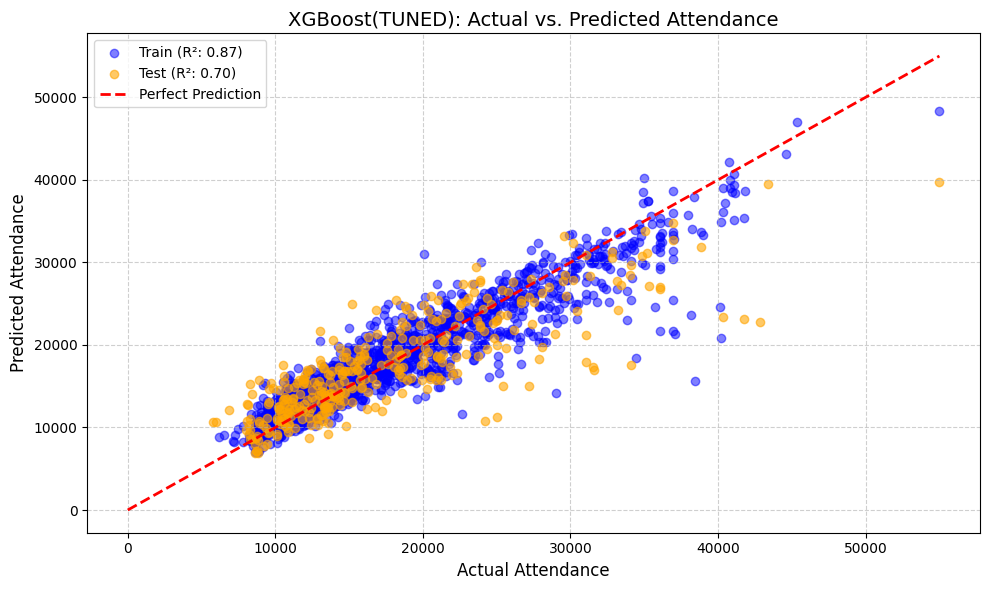

In [65]:
# Create the plotting data
plt.figure(figsize=(10, 6))

# Scatter plot for Training Data
plt.scatter(y_train, y_pred_train, alpha=0.5, label=f'Train (R²: {train_r2:.2f})', color='blue')

# Scatter plot for Test Data
plt.scatter(y_test, y_pred_test, alpha=0.6, label=f'Test (R²: {test_r2:.2f})', color='orange')

# Identity line (Perfect Prediction)
max_val = max(y_train.max(), y_test.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.title('XGBoost(TUNED): Actual vs. Predicted Attendance', fontsize=14)
plt.xlabel('Actual Attendance', fontsize=12)
plt.ylabel('Predicted Attendance', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

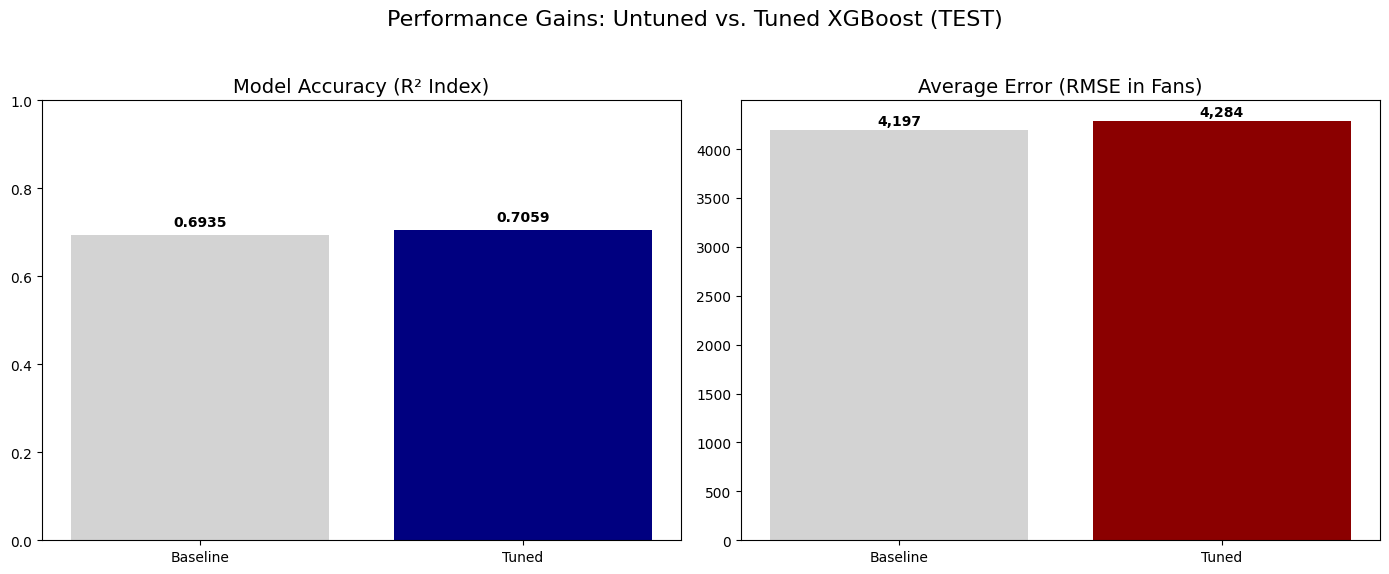

In [66]:
# Data from previous cells:
# Baseline XGBoost
# Tuned XGBoost

comparison_data = {
    'Metric': ['R-Squared', 'R-Squared', 'RMSE (Fans)', 'RMSE (Fans)'],
    'Model': ['Baseline', 'Tuned', 'Baseline', 'Tuned'],
    'Value': [0.6935, 0.7059, 4284.23, 4196.79]
}

df_comp = pd.DataFrame(comparison_data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot R-Squared
bars1 = ax1.bar(['Baseline', 'Tuned'], [0.6935, 0.7059], color=['lightgrey', 'navy'])
ax1.set_title('Model Accuracy (R² Index)', fontsize=14)
ax1.set_ylim(0, 1.0)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.4f}', ha='center', fontweight='bold')

# Plot RMSE
bars2 = ax2.bar(['Baseline', 'Tuned'], [4196.79, 4284.23], color=['lightgrey', 'darkred'])
ax2.set_title('Average Error (RMSE in Fans)', fontsize=14)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 50, f'{height:,.0f}', ha='center', fontweight='bold')

plt.suptitle('Performance Gains: Untuned vs. Tuned XGBoost (TEST)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [67]:
import matplotlib.pyplot as plt
import pandas as pd

best_model = rs.best_estimator_

# Three types of importance
importance_types = ['weight', 'gain', 'cover']
for imp_type in importance_types:
    importance = best_model.get_booster().get_score(importance_type=imp_type)
    importance_df = pd.DataFrame(list(importance.items()), columns=['Feature', imp_type])
    importance_df = importance_df.sort_values(imp_type, ascending=False)
    print(f"\nTop features by {imp_type}:\n", importance_df.head(10))


Top features by weight:
                   Feature  weight
0                  season  4063.0
1                   month  2164.0
3        parsed_starttime  1209.0
2              is_weekend   396.0
7                 opp_BOS   393.0
21                opp_NYA   364.0
39    day_of_week_Tuesday   339.0
35     day_of_week_Monday   333.0
40  day_of_week_Wednesday   324.0
6                 opp_BAL   316.0

Top features by gain:
                  Feature         gain
33    gametype_x_regular  416744192.0
21               opp_NYA  294264544.0
2             is_weekend  280581600.0
7                opp_BOS  142445776.0
36  day_of_week_Saturday  113987920.0
0                 season  110700376.0
5                opp_ATL   98063656.0
22               opp_NYN   61031604.0
27               opp_SFN   55425540.0
10               opp_CLE   51106896.0

Top features by cover:
                Feature        cover
31             opp_WAS  1022.375000
11             opp_COL  1006.595215
28             opp_SLN  1

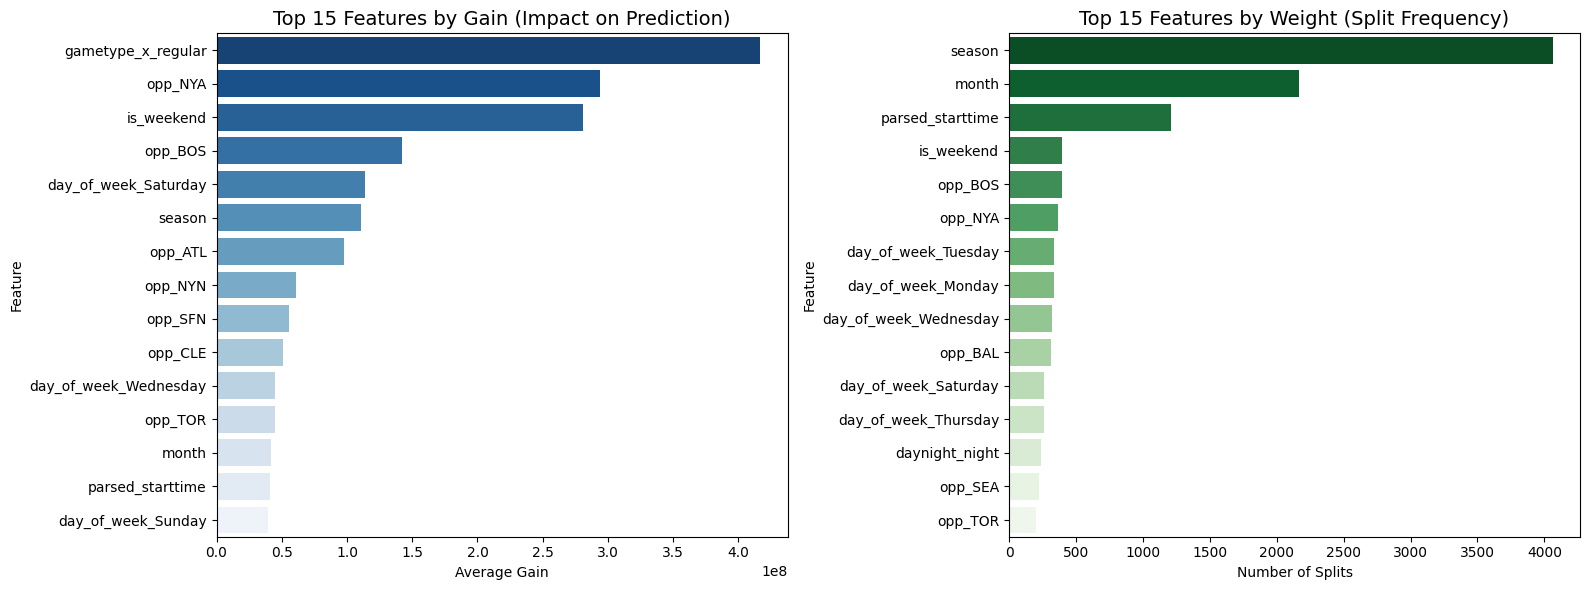

In [68]:
# Create a multi-plot figure to show different importance types
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gain Importance (Predictive Power)
# This tells us which features contribute most to the accuracy of the attendance estimate
importance_gain = best_model.get_booster().get_score(importance_type='gain')
importance_gain_df = pd.DataFrame(list(importance_gain.items()), columns=['Feature', 'Gain']).sort_values('Gain', ascending=False).head(15)

sns.barplot(x='Gain', y='Feature', data=importance_gain_df, ax=axes[0], palette='Blues_r', hue='Feature', legend=False)
axes[0].set_title('Top 15 Features by Gain (Impact on Prediction)', fontsize=14)
axes[0].set_xlabel('Average Gain')

# 2. Weight Importance (Frequency)
# This tells us which features are used most often across all the trees
importance_weight = best_model.get_booster().get_score(importance_type='weight')
importance_weight_df = pd.DataFrame(list(importance_weight.items()), columns=['Feature', 'Weight']).sort_values('Weight', ascending=False).head(15)

sns.barplot(x='Weight', y='Feature', data=importance_weight_df, ax=axes[1], palette='Greens_r', hue='Feature', legend=False)
axes[1].set_title('Top 15 Features by Weight (Split Frequency)', fontsize=14)
axes[1].set_xlabel('Number of Splits')

plt.tight_layout()
plt.show()


<div style="border: 2px solid #4a90d9; border-radius: 8px; padding: 20px; background-color: #f9f9f9; font-family: Arial, sans-serif; max-width: 900px;">

<h3 style="color: #2c3e50;">1. Top Features by Gain (The "Impact" Players)</h3>
<p>Gain measures how much a feature improves the model's accuracy, lets take this step by step when we use the model features and make a split it reduces errors and your attendance prediction.</p>
<ul>
  <li><strong>gametype_x_regular:</strong> This is the most powerful feature. It suggests that whether a game is a "regular" game vs. an exhibition or special event is the single biggest factor in swinging the attendance numbers.</li>
  <li><strong>The "Big Names" (opp_NYA, opp_BOS):</strong> In sports modeling, certain teams (like the Yankees or Red Sox) are massive draws because the model sees that its a high profile team it will immediately predict that the stadium is packed.</li>
  <li><strong>is_weekend &amp; day_of_week_Saturday/Sunday:</strong> These are high-impact features. The model finds that the jump in attendance from a Tuesday to a Saturday is very predictable and significant.</li>
</ul>

<h3 style="color: #2c3e50;">2. Top Features by Weight (The "Workhorses")</h3>
<p>Weight (or Frequency) measures how many times a feature is used to split the data across all the trees in your model. This represents "quantity."</p>
<ul>
  <li><strong>season and month:</strong> the model always uses it as anchor points before even looking at who is playing because when it knows when they are playing it can predict it for a trend such as summer months because generally they have higher attendance than early spring.</li>
  <li><strong>parsed_starttime:</strong> This is a high-frequency splitter. The model is constantly checking the time of day to fine-tune the prediction, even if the "Gain" (the specific impact of one hour vs. another) isn't as massive as a weekend vs. weekday.</li>
</ul>

<h3 style="color: #2c3e50;">3. The "Why the Difference?" Insight</h3>
<p>You'll notice that season is #1 in Weight but much lower in Gain. Conversely, gametype_x_regular is #1 in Gain but doesn't even appear in the top 15 for Weight. Here is what that means for your data:</p>
<ul>
  <li><strong>Broad Filters (High Weight):</strong> The model uses season and month to sort the data over and over again. They are necessary for the model's structure, but they don't always provide the "final" answer.</li>
  <li><strong>Decision Makers (High Gain):</strong> Features like is_weekend or opp_NYA are the "final word." Once the model knows it's a Saturday game against a popular opponent, it can make a very high-confidence prediction. It doesn't need to split on these features many times to get the point.</li>
</ul>

<h3 style="color: #2c3e50;">Summary for your Attendance Model</h3>
<p>If you want to increase attendance, your model suggests you should focus on:</p>
<ol>
  <li><strong>Scheduling/Marketing:</strong> Capitalize on the weekend/Saturday surge.</li>
  <li><strong>Opponent Strategy:</strong> You know exactly which opponents (NYA, BOS, ATL) drive the most "predictable" spikes in revenue.</li>
  <li><strong>Seasonality:</strong> Use the season and month trends as your baseline, but look to the "Gain" features to see what actually moves the needle beyond just the time of year.</li>
</ol>

</div>


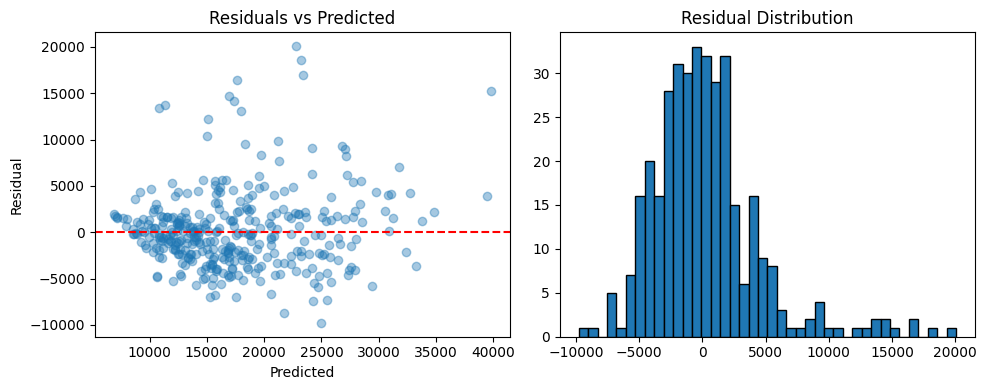

In [69]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 4))

# Residuals vs predicted
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted"); plt.ylabel("Residual")
plt.title("Residuals vs Predicted")

# Distribution of errors
plt.subplot(1, 2, 2)
plt.hist(residuals, bins=40, edgecolor='black')
plt.title("Residual Distribution")

plt.tight_layout()
plt.show()

In [70]:
cv_results = pd.DataFrame(rs.cv_results_)
cv_results = cv_results.sort_values('rank_test_score')

# See how each param affected R²
print(cv_results[['param_learning_rate', 'param_max_depth',
                   'param_n_estimators', 'mean_test_score']].head(20))

    param_learning_rate  param_max_depth  param_n_estimators  mean_test_score
6                  0.03                5                 800         0.703312
12                 0.03                4                1200         0.703157
9                  0.03                6                 500         0.702768
20                 0.05                5                1200         0.702764
14                 0.05                5                 800         0.702326
69                 0.10                3                 800         0.700880
66                 0.05                5                 500         0.700564
52                 0.10                4                 500         0.700202
29                 0.05                5                 500         0.699834
67                 0.10                5                 500         0.699721
63                 0.03                6                 800         0.699102
8                  0.03                5                 800    

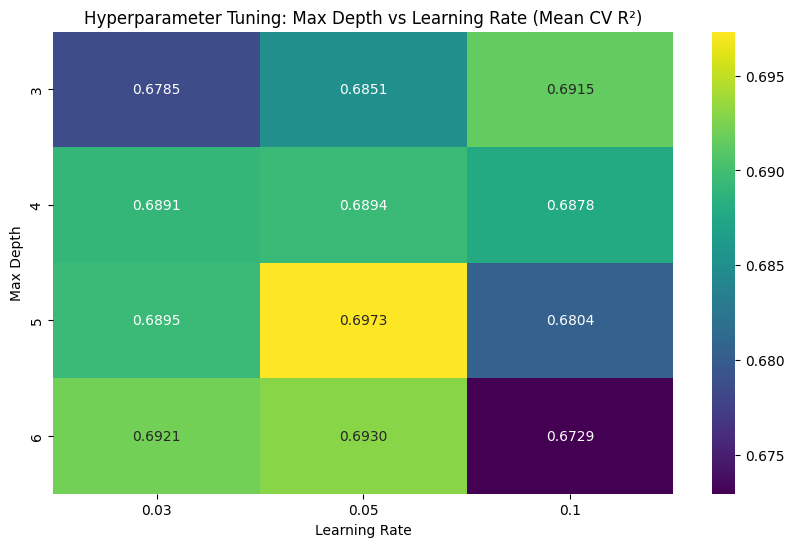

In [71]:
# Pivot the data for the heatmap
# We'll take the mean of mean_test_score for cases where there are multiple entries for a pair
pivot_table = cv_results.pivot_table(
    index='param_max_depth',
    columns='param_learning_rate',
    values='mean_test_score',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt='.4f')
plt.title('Hyperparameter Tuning: Max Depth vs Learning Rate (Mean CV R²)')
plt.xlabel('Learning Rate')
plt.ylabel('Max Depth')
plt.show()



<div style="border: 2px solid #4a90d9; border-radius: 8px; padding: 20px; background-color: #f9f9f9; font-family: Arial, sans-serif; max-width: 900px;">

<h2 style="color: #2c3e50;">Business Recommendations for Improving Tampa Bay Rays Home Attendance</h2>

<p>To boost Home attendance in the Tampa Bay Rays we went by our comprehensive analysis of game-level data, that was optimized from the XGBoost model and identified several key areas.</p>

<h3 style="color: #2c3e50;">1. Strategic Scheduling &amp; Game Timing</h3>
<ul>
  <li><strong>Prioritize Weekend &amp; Evening Games:</strong> from our analysis we have collected data about when is the higher attendance which are on Saturday and Sunday games also the exact times which are 5 PM and 8 pm that mostly have more high-profile games.</li>
  <li><strong>Leverage Early &amp; Late Season:</strong> the excitement of the start and the end of the season which makes the fans attend more games which has been documented in March and October.</li>
</ul>

<h3 style="color: #2c3e50;">2. Opponent-Based Marketing &amp; Promotions</h3>
<ul>
  <li><strong>Target Popular Opponents:</strong> Teams like the New York Yankees (NYA), Boston Red Sox (BOS), Atlanta Braves (ATL), Chicago Cubs (CHN), and San Francisco Giants (SFN) consistently draw larger crowds which means more marketing and premium pricing especially for games against these popular opponents.</li>
  <li><strong>Bundle Less Popular Games:</strong> creating promotion for families also ticket packages for games that have lower attendance mainly in middle of the week games.</li>
</ul>

<h3 style="color: #2c3e50;">3. Enhance Game Day Experience &amp; Value</h3>
<ul>
  <li><strong>Focus on 'Event' Games:</strong> Playoff games like the World Series, LCS actually draws the biggest crowds. Most fans come to these games because its the most important ones, from these events the team should take ideas and apply them on regular season games to make the other games feel the energy of the most important games by adding giveaways and promotions like season pass.</li>
  <li><strong>Monitor Game Performance, But Don't Overreact to Single Games:</strong> Our analysis suggests that the loss in the previous games does not significantly deter attendance for the next home game. This shows that the fan base's decision is influenced by broader factors rather than immediate team performance fluctuations.</li>
</ul>

<h3 style="color: #2c3e50;">4. Continuous Analysis &amp; Adaptation</h3>
<ul>
  <li><strong>Dynamic Pricing &amp; Promotion:</strong> adjusting pricing accordingly from monitoring attendance trends it gives leverage insight to the model forecast expecting attendance.</li>
  <li><strong>Explore Weather-Related Strategies:</strong> Weather factors might affect attendance such as heavy rain and discourage travel because the Tropicana Field is a dome, we need to investigate more to give the fans comfort and accessibility to the stadium.</li>
</ul>

<h3 style="color: #2c3e50;">5. Payroll Investment vs. Attendance (Long-Term Consideration)</h3>
<ul>
  <li>Payroll investment and attendance is not connected directly to each other simply teams always linked to pay roll while attendance is not if you pay more doesn't mean you will have higher attendance, marketing has to be involved so both categories can link together for a better strategic investment.</li>
</ul>

</div>


# Limitation

<ul>
  <li>A crucial factor we fail to take into consideratoin is that when the stadium trap or cover is up it holds up to 25,000 and 42,735 fans in attendance</li>
</ul>

In [72]:
!jupyter nbconvert --to html "Final_Project_MLB.ipynb"

[NbConvertApp] WARNING | pattern 'Final_Project_MLB.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execu